# 05A — Estimación de Flujo Vertical: Método Hatch-Amplitude (Cabecera)

## Análisis de Datos de Terreno — Río Cuncumen

> **Método principal**: Hatch-Amplitude (Hatch et al., 2006) — Solo atenuación de amplitud  
> **Método de validación**: McCallum (McCallum et al., 2012) — Ratio de amplitudes + desfase combinado  
> **Versión**: Marzo 2026 | **Parámetros térmicos**: Laboratorio IDIEM por TC  
> **Referencia metodológica**: Saphores et al. (2024) — Justifica Hatch-Amplitude como método base

---

### Justificación del Método Cabecera

Saphores et al. (2024) analizan las distintas metodologías de ecuaciones de flujo de calor y estimación de infiltraciones,
concluyendo que el método **Hatch-Amplitude** es el más robusto y estable por:

- Depende **exclusivamente** del ratio de amplitudes $A_r = A_{sup}/A_{prof}$
- **No requiere estimación de fase**, evitando la principal fuente de error (separación Δφ conductivo/advectivo)
- Menor sensibilidad a ruido instrumental y condiciones de borde transitorias
- Consistencia documentada en Suárez et al. (2023) para el Río Silala

### Ecuación Hatch-Amplitude

$$q_z = \frac{2 \cdot \alpha_e}{\Delta z} \cdot \ln\left(\frac{A_{sup}}{A_{prof}}\right)$$

donde:
- $\alpha_e = \lambda / C_s$ es la difusividad térmica efectiva (medida en laboratorio IDIEM)
- $\Delta z$ es la separación entre sensores (m)
- $A_{sup}, A_{prof}$ son las amplitudes del armónico diario de cada sensor (°C)

### Ecuación McCallum (Validación)

$$\gamma = \sqrt{\Delta\phi^2 + \ln(A_r)^2}$$
$$K_e = \frac{\omega \cdot \Delta z^2 \cdot \Delta\phi}{2 \cdot \gamma^2}$$
$$q_z = \frac{2 K_e}{\Delta z} \cdot \frac{C_w}{C_s} \cdot \frac{\gamma \cdot \ln(A_r)}{2 \cdot \Delta\phi}$$

### Parámetros Térmicos

**ACTUALIZACIÓN**: Se utilizan propiedades térmicas medidas en laboratorio (IDIEM, Feb-Mar 2026)
en lugar de valores genéricos de literatura. Cada TC tiene sus propios parámetros.

| TC | λ (W/m·K) | C_s (MJ/m³·K) | α (m²/s) | K_v (m/d) | Tipo suelo USCS |
|:--:|:---------:|:-------------:|:--------:|:---------:|:---------------:|
| TC-1 | 0.614 | 3.389 | 2.03×10⁻⁷ | 0.003 | SP-SM |
| TC-2 | 0.258 | 5.333 | 4.90×10⁻⁸ | 0.002 | SM |
| TC-3 | 0.265 | 4.867 | 5.50×10⁻⁸ | 0.006 | SW-SM |
| TC-4 | 0.666 | 2.342 | 3.13×10⁻⁷ | 0.778 | GP-GM |
| TC-5 | 0.578 | 2.690 | 2.24×10⁻⁷ | 0.003 | SW-SM |

### Instrumentación

| Parámetro | Valor |
|-----------|-------|
| **Sensores** | iButton DS1922L / DS1923 |
| **Resolución** | 0.0625 °C (DS1922L), 0.5 °C (DS1923) |
| **Muestreo** | 30 min |
| **TC1, TC4, TC5** | 21-dic-25 16:00 → 25-feb-26 12:00 (~66 días) |
| **TC2, TC3** | 23-ene-26 13:00 → 25-feb-26 12:00 (~33 días) |
| **Profundidades** | TC1/TC4/TC5: 0.00, 0.28, 0.56 m; TC2/TC3: 0.00, 0.20, 0.40 m |
| **Pares de sensores** | 15 pares (3 × 5 estaciones) |

### Pipeline de procesamiento

1. **Carga de datos** — 5 termocuplas desde Excel filtrados
2. **Parámetros térmicos IDIEM** — Valores de laboratorio por TC
3. **Análisis armónico** — Ajuste sinusoidal (período 24h, ventanas de 60 días)
4. **Hatch-Amplitude** — Método cabecera con α medida
5. **McCallum** — Validación cruzada
6. **Series temporales** — Ventanas deslizantes 48h
7. **Métricas de confiabilidad** — Enfocadas en Hatch-Amp y McCallum
8. **Incertidumbre** — Propagación con propiedades lab
9. **Flujo promedio por TC** — Promediando todos los pares
10. **Exportación** — Excel con incertidumbre

---
## 1. Carga de Datos y Configuración

In [19]:
# ==========================================================================
# CELDA 1: Imports y Carga de Datos de las 5 Termocuplas
# ==========================================================================
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import warnings
warnings.filterwarnings('ignore')

# Directorio raíz del proyecto
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

# Cargar módulos del proyecto
from vfluxx.harmonic_analysis import fit_harmonic_model, analyze_sensor_pair
from vfluxx.vflux_methods import calculate_vflux_all_methods
from vfluxx.io_utils import ibuttons_to_dataframe
from vfluxx.preprocess import align_and_resample
from vfluxx.flux_timeseries import calculate_flux_timeseries, batch_calculate_flux_timeseries, export_flux_timeseries

# Cargar datos Excel filtrados de las 5 TCs
new_data_dir = project_root / 'data' / 'Datos Termocuplas 25-02-2026'
tc1_df = pd.read_excel(new_data_dir / 'tc1' / 'datos_filtrados_tc1.xlsx')
tc2_df = pd.read_excel(new_data_dir / 'tc2' / 'datos_filtrados_tc2.xlsx')
tc3_df = pd.read_excel(new_data_dir / 'tc3' / 'datos_filtrados_tc3.xlsx')
tc4_df = pd.read_excel(new_data_dir / 'tc4' / 'datos_filtrados_tc4.xlsx')
tc5_df = pd.read_excel(new_data_dir / 'tc5' / 'datos_filtrados_tc5.xlsx')

# Construir lista de sensores (misma lógica que 05_datos_terreno)
sensors = []
sensor_mappings = {
    'tc1': (tc1_df, [
        ('A400000082BAF041', 'temp1', 'fecha1', 'DS1923'),
        ('7D000000828FA841', 'temp2', 'fecha2', 'DS1922L'),
        ('5900000082B86A41', 'temp3', 'fecha3', 'DS1923'),
    ]),
    'tc2': (tc2_df, [
        ('2E000000828FF441', 'temp1', 'fecha1', 'DS1922L'),
        ('4600000082991C41', 'temp2', 'fecha2', 'DS1922L'),
        ('4B0000008298EA41', 'temp3', 'fecha3', 'DS1922L'),
    ]),
    'tc3': (tc3_df, [
        ('0600000082994E41', 'temp1', 'fecha1', 'DS1922L'),
        ('870000008290BE41', 'temp2', 'fecha2', 'DS1922L'),
        ('98000000828FD441', 'temp3', 'fecha3', 'DS1922L'),
    ]),
    'tc4': (tc4_df, [
        ('F60000008290D841', 'temp1', 'fecha1', 'DS1922L'),
        ('2D00000082925E41', 'temp2', 'fecha2', 'DS1922L'),
        ('B3000000828F2741', 'temp3', 'fecha3', 'DS1922L'),
    ]),
    'tc5': (tc5_df, [
        ('3800000082952A41', 'temp1', 'fecha1', 'DS1922L'),
        ('B000000082987741', 'temp2', 'fecha2', 'DS1922L'),
        ('2800000082978041', 'temp3', 'fecha3', 'DS1922L'),
    ]),
}

for tc_name, (tc_df, mapping) in sensor_mappings.items():
    for sid, temp_col, date_col, pn in mapping:
        df_sensor = pd.DataFrame({
            'datetime': pd.to_datetime(tc_df[date_col]),
            'temperature': tc_df[temp_col]
        }).dropna()
        sensors.append({
            'df': df_sensor, 'sensor_id': sid,
            'part_number': pn, 'metadata': {'Registration Number': sid}
        })

sensors = sorted(sensors, key=lambda x: x['sensor_id'])
sensor_labels = [f'temp_{i+1}' for i in range(len(sensors))]

print(f"{'='*80}")
print(f" DATOS CARGADOS: 5 Termocuplas Río Cuncumén ".center(80))
print(f"{'='*80}")
print(f"\n{'#':<4} {'Sensor ID':<22} {'Tipo':<10} {'N':<8} {'Inicio':<12} {'Fin':<12} {'T min':<8} {'T max':<8}")
print("-" * 88)
for i, s in enumerate(sensors):
    df_s = s['df']
    print(f"{i+1:<4} {s['sensor_id'][:20]:<22} {s['part_number']:<10} {len(df_s):<8} "
          f"{df_s['datetime'].min().strftime('%d-%b-%y'):<12} {df_s['datetime'].max().strftime('%d-%b-%y'):<12} "
          f"{df_s['temperature'].min():<8.2f} {df_s['temperature'].max():<8.2f}")
print(f"\n✔ {len(sensors)} sensores cargados exitosamente")

                   DATOS CARGADOS: 5 Termocuplas Río Cuncumén                   

#    Sensor ID              Tipo       N        Inicio       Fin          T min    T max   
----------------------------------------------------------------------------------------
1    0600000082994E41       DS1922L    1582     23-ene.-26   25-feb.-26   11.67    43.28   
2    2800000082978041       DS1922L    3160     21-dic.-25   25-feb.-26   16.45    26.52   
3    2D00000082925E41       DS1922L    3160     21-dic.-25   25-feb.-26   12.80    26.69   
4    2E000000828FF441       DS1922L    1582     23-ene.-26   25-feb.-26   12.90    25.73   
5    3800000082952A41       DS1922L    3160     21-dic.-25   25-feb.-26   12.79    24.06   
6    4600000082991C41       DS1922L    1582     23-ene.-26   25-feb.-26   15.07    19.96   
7    4B0000008298EA41       DS1922L    1582     23-ene.-26   25-feb.-26   15.80    18.99   
8    5900000082B86A41       DS1923     3160     21-dic.-25   25-feb.-26   14.73    28.90   
9

---
## 2. Configuración Maestra: Sensores, Profundidades y Parámetros IDIEM

In [20]:
# ==========================================================================
# CELDA 2: Mapeo de sensores + Parámetros Térmicos LABORATORIO IDIEM
# ==========================================================================

# --- Mapeo sensor → TC → profundidad (idéntico a 05_datos_terreno) ---
TC_CONFIG = {
    'TC1': {'surface': 'temp_12', 'intermediate': 'temp_9',  'deep': 'temp_8'},
    'TC2': {'surface': 'temp_4',  'intermediate': 'temp_6',  'deep': 'temp_7'},
    'TC3': {'surface': 'temp_1',  'intermediate': 'temp_10', 'deep': 'temp_11'},
    'TC4': {'surface': 'temp_15', 'intermediate': 'temp_3',  'deep': 'temp_14'},
    'TC5': {'surface': 'temp_5',  'intermediate': 'temp_13', 'deep': 'temp_2'},
}

depths_m = {
    'temp_12': 0.00, 'temp_9': 0.28, 'temp_8': 0.56,   # TC1
    'temp_4': 0.00, 'temp_6': 0.20, 'temp_7': 0.40,    # TC2
    'temp_1': 0.00, 'temp_10': 0.20, 'temp_11': 0.40,  # TC3
    'temp_15': 0.00, 'temp_3': 0.28, 'temp_14': 0.56,  # TC4
    'temp_5': 0.00, 'temp_13': 0.28, 'temp_2': 0.56,   # TC5
}

tc_assignment = {
    'temp_8': 'TC1', 'temp_9': 'TC1', 'temp_12': 'TC1',
    'temp_4': 'TC2', 'temp_6': 'TC2', 'temp_7': 'TC2',
    'temp_1': 'TC3', 'temp_10': 'TC3', 'temp_11': 'TC3',
    'temp_3': 'TC4', 'temp_14': 'TC4', 'temp_15': 'TC4',
    'temp_2': 'TC5', 'temp_5': 'TC5', 'temp_13': 'TC5',
}

ACTIVE_TCS = ['TC1', 'TC2', 'TC3', 'TC4', 'TC5']

STATION_COORDS_UTM = {
    'TC1': {'easting': 347285, 'northing': 6473381},
    'TC2': {'easting': 347440, 'northing': 6473566},
    'TC3': {'easting': 347087, 'northing': 6472284},
    'TC4': {'easting': 347113, 'northing': 6472121},
    'TC5': {'easting': 346618, 'northing': 6471135},
}

# ==========================================================================
# PARÁMETROS TÉRMICOS DE LABORATORIO IDIEM (Feb-Mar 2026)
# Informes:
#   - IDIEM N°1: TC1, TC4, TC5 (código 2.172.933-A, 06-feb-2026)
#   - IDIEM N°2: TC2, TC3 (código 2.172.933-B, 02-mar-2026)
# ==========================================================================
THERMAL_PARAMS_LAB = {
    'TC1': {
        'lambda_sediment': 0.614,   # W/m·K (medido IDIEM)
        'C_sediment': 3.389e6,      # J/m³·K (medido IDIEM)
        'alpha_e': 2.03e-7,         # m²/s (medido IDIEM, NO calculado)
        'C_water': 4.18e6,          # J/m³·K (constante física)
        'omega': 2 * np.pi / 86400, # rad/s (ciclo diario)
        'density_dry': 1.10,        # g/cm³
        'K_v': 0.0026,              # m/d (permeabilidad vertical)
        'USCS': 'SP-SM',            # Arena mal gradada con limo
    },
    'TC2': {
        'lambda_sediment': 0.258,
        'C_sediment': 5.333e6,
        'alpha_e': 4.90e-8,
        'C_water': 4.18e6,
        'omega': 2 * np.pi / 86400,
        'density_dry': 1.52,
        'K_v': 0.0016,
        'USCS': 'SM',
    },
    'TC3': {
        'lambda_sediment': 0.265,
        'C_sediment': 4.867e6,
        'alpha_e': 5.50e-8,
        'C_water': 4.18e6,
        'omega': 2 * np.pi / 86400,
        'density_dry': 1.39,
        'K_v': 0.0058,
        'USCS': 'SW-SM',
    },
    'TC4': {
        'lambda_sediment': 0.666,
        'C_sediment': 2.342e6,
        'alpha_e': 3.13e-7,
        'C_water': 4.18e6,
        'omega': 2 * np.pi / 86400,
        'density_dry': 1.37,
        'K_v': 0.778,
        'USCS': 'GP-GM',
    },
    'TC5': {
        'lambda_sediment': 0.578,
        'C_sediment': 2.690e6,
        'alpha_e': 2.24e-7,
        'C_water': 4.18e6,
        'omega': 2 * np.pi / 86400,
        'density_dry': 1.22,
        'K_v': 0.0031,
        'USCS': 'SW-SM',
    },
}

# Períodos de registro actualizados por TC (con hora exacta de terreno)
TC_PERIODS = {
    'TC1': ('2025-12-21 16:00', '2026-02-25 12:00'),  # ~66 días
    'TC2': ('2026-01-23 13:00', '2026-02-25 12:00'),  # ~33 días
    'TC3': ('2026-01-23 13:00', '2026-02-25 12:00'),  # ~33 días
    'TC4': ('2025-12-21 16:00', '2026-02-25 12:00'),  # ~66 días
    'TC5': ('2025-12-21 16:00', '2026-02-25 12:00'),  # ~66 días
}

# Imprimir tabla de parámetros IDIEM
print('█' * 80)
print(' PARÁMETROS TÉRMICOS DE LABORATORIO IDIEM '.center(80, '█'))
print('█' * 80)
print(f"\n{'TC':<6} {'λ (W/m·K)':<12} {'C_s (MJ/m³·K)':<16} {'α (m²/s)':<14} {'K_v (m/d)':<12} {'USCS':<12}")
print('=' * 78)
for tc in ACTIVE_TCS:
    p = THERMAL_PARAMS_LAB[tc]
    d_pen = np.sqrt(2 * p['alpha_e'] / p['omega'])
    print(f"{tc:<6} {p['lambda_sediment']:<12.3f} {p['C_sediment']/1e6:<16.3f} "
          f"{p['alpha_e']:<14.2e} {p['K_v']:<12.4f} {p['USCS']:<12}")

print(f"\n{'TC':<6} {'ρ_seca (g/cm³)':<16} {'d penetración (cm)':<22} {'Período registro':<22}")
print('=' * 68)
for tc in ACTIVE_TCS:
    p = THERMAL_PARAMS_LAB[tc]
    d_pen = np.sqrt(2 * p['alpha_e'] / p['omega']) * 100
    start, end = TC_PERIODS[tc]
    dias = (pd.Timestamp(end) - pd.Timestamp(start)).days
    print(f"{tc:<6} {p['density_dry']:<16.2f} {d_pen:<22.1f} {start} → {end} ({dias}d)")

print(f"\n⚠️  NOTA: La difusividad térmica α es un RESULTADO DE LABORATORIO,")
print(f"   no se calcula como λ/C_s. Valores IDIEM directos.")
print(f"\n⚠️  Los parámetros anteriores (λ=1.80, C_s=2.80 MJ/m³·K) eran de LITERATURA.")
print(f"   Los valores de laboratorio muestran heterogeneidad significativa entre TCs.")

████████████████████████████████████████████████████████████████████████████████
███████████████████ PARÁMETROS TÉRMICOS DE LABORATORIO IDIEM ███████████████████
████████████████████████████████████████████████████████████████████████████████

TC     λ (W/m·K)    C_s (MJ/m³·K)    α (m²/s)       K_v (m/d)    USCS        
TC1    0.614        3.389            2.03e-07       0.0026       SP-SM       
TC2    0.258        5.333            4.90e-08       0.0016       SM          
TC3    0.265        4.867            5.50e-08       0.0058       SW-SM       
TC4    0.666        2.342            3.13e-07       0.7780       GP-GM       
TC5    0.578        2.690            2.24e-07       0.0031       SW-SM       

TC     ρ_seca (g/cm³)   d penetración (cm)     Período registro      
TC1    1.10             7.5                    2025-12-21 16:00 → 2026-02-25 12:00 (65d)
TC2    1.52             3.7                    2026-01-23 13:00 → 2026-02-25 12:00 (32d)
TC3    1.39             3.9            

---
## 3. Preparación de Datos y Alineación Temporal

In [21]:
# ==========================================================================
# CELDA 3: Combinar sensores, alinear y remuestrear a 30 min
# ==========================================================================
df_raw = ibuttons_to_dataframe(sensors, sensor_labels=sensor_labels)

# Período de análisis completo
cutoff_start = pd.Timestamp('2025-12-21 16:00')
cutoff_end   = pd.Timestamp('2026-02-25 12:00')

# Alinear a grilla de 30 min
df_aligned = align_and_resample(df_raw, freq='30min')
mapped_sensors = list(tc_assignment.keys())

# Directorios de salida
out_dir = project_root / 'resultados_python' / 'terreno_2026_hatch'
out_dir.mkdir(parents=True, exist_ok=True)
img_dir = project_root / 'image' / 'terreno_2026'
img_dir.mkdir(parents=True, exist_ok=True)

print(f"{'='*70}")
print(f" DATOS PREPARADOS ".center(70))
print(f"{'='*70}")
print(f"DataFrame alineado: {len(df_aligned)} registros × {len(df_aligned.columns)} columnas")
print(f"Período: {df_aligned['fecha'].min()} → {df_aligned['fecha'].max()}")
print(f"TC1/TC4/TC5: 21-dic-25 16:00 → 25-feb-26 12:00 (~66 días)")
print(f"TC2/TC3: 23-ene-26 13:00 → 25-feb-26 12:00 (~33 días)")
print(f"Directorio de salida: {out_dir.relative_to(project_root)}")

✔ Alineación temporal completada:
  • Registros: 24675 → 3160 (freq=30min)
  • Sensores: 15
  • Periodo: 2025-12-21 16:00:00 → 2026-02-25 11:30:00
  • Valores NaN restantes: 9468
                           DATOS PREPARADOS                           
DataFrame alineado: 3160 registros × 16 columnas
Período: 2025-12-21 16:00:00 → 2026-02-25 11:30:00
TC1/TC4/TC5: 21-dic-25 16:00 → 25-feb-26 12:00 (~66 días)
TC2/TC3: 23-ene-26 13:00 → 25-feb-26 12:00 (~33 días)
Directorio de salida: resultados_python\terreno_2026_hatch


---
## 4. Series Temporales de Temperatura

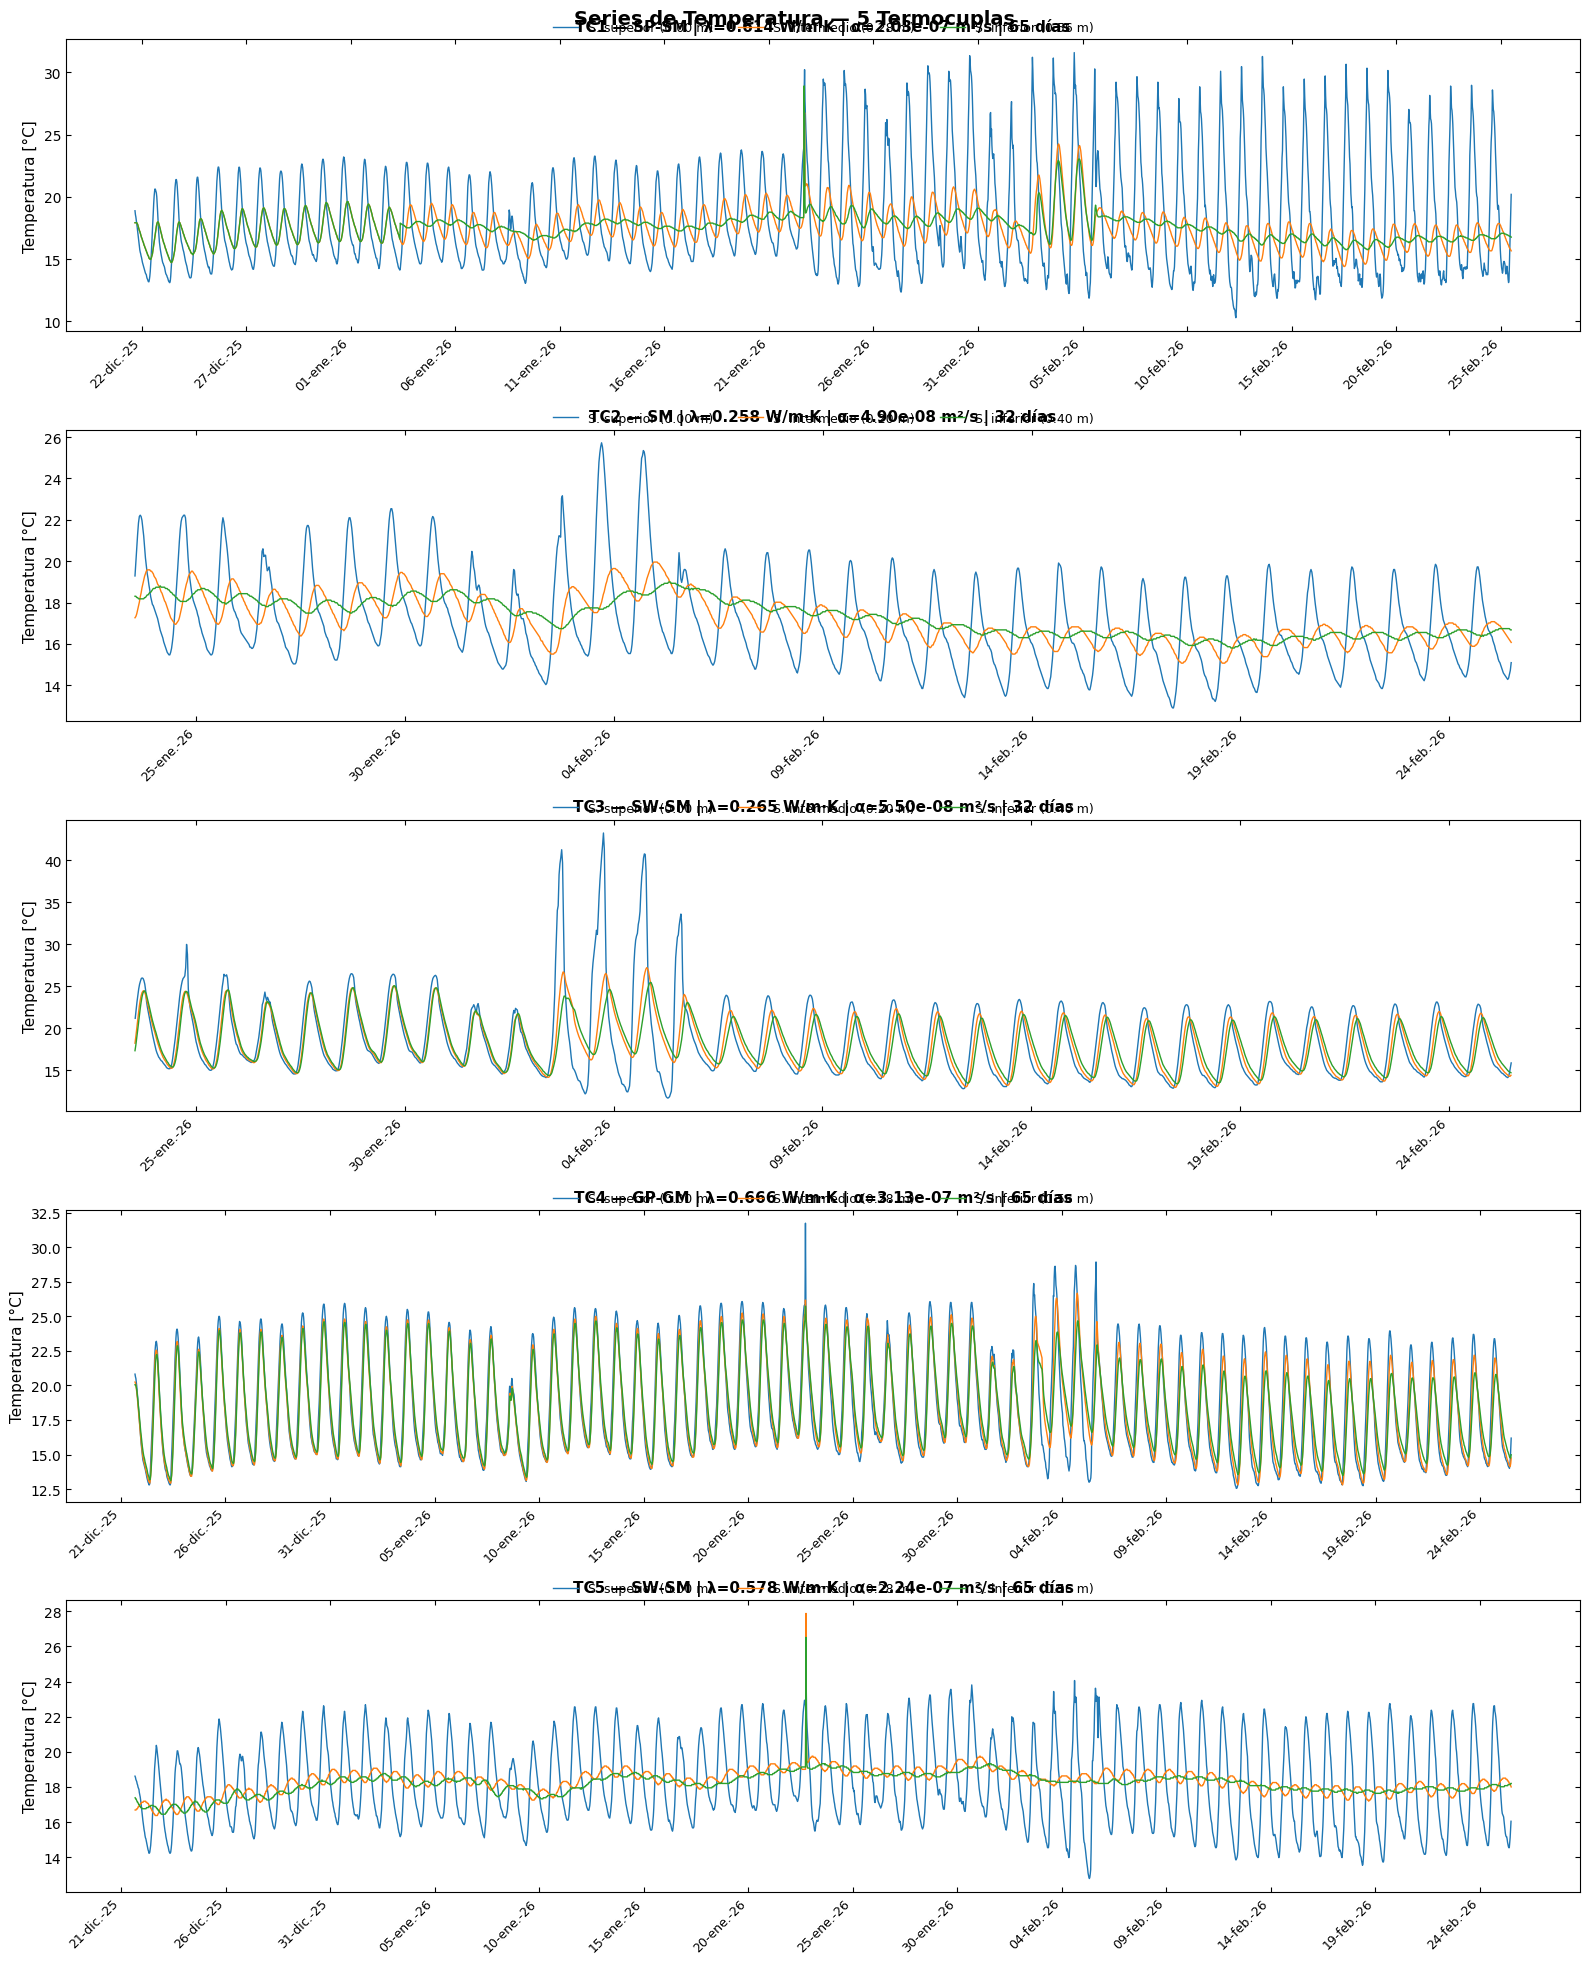

In [23]:
# ==========================================================================
# CELDA 4: Series de Temperatura por TC (formato fechas: 01-ene-26)
# ==========================================================================
import locale
try:
    locale.setlocale(locale.LC_TIME, 'es_ES.UTF-8')
except:
    try:
        locale.setlocale(locale.LC_TIME, 'Spanish_Spain.1252')
    except:
        pass  # Usar formato por defecto si no está disponible

# Paleta de colores MATLAB-style por posición
tc_colors_matlab = {'surface': '#1f77b4', 'intermediate': '#ff7f0e', 'deep': '#2ca02c'}
pos_labels = {'surface': 'S. superior', 'intermediate': 'S. intermedio', 'deep': 'S. inferior'}

# Colores por TC 
TC_COLORS = {
    'TC1': '#1f77b4', 'TC2': '#ff7f0e', 'TC3': '#2ca02c',
    'TC4': '#9467bd', 'TC5': '#d62728',
}

# Formato de fecha español: 01-ene-26
DATE_FMT = '%d-%b-%y'

n_tcs = len(ACTIVE_TCS)
fig, axes = plt.subplots(n_tcs, 1, figsize=(16, 4*n_tcs), facecolor='white')

for ax, tc_name in zip(axes, ACTIVE_TCS):
    tc_map = TC_CONFIG[tc_name]
    ax.set_facecolor('white')
    
    tc_start = pd.Timestamp(TC_PERIODS[tc_name][0])
    tc_end = pd.Timestamp(TC_PERIODS[tc_name][1])
    
    for pos in ['surface', 'intermediate', 'deep']:
        label = tc_map[pos]
        d_m = depths_m[label]
        mask = (df_raw['fecha'] >= tc_start) & (df_raw['fecha'] <= tc_end)
        df_plot = df_raw[mask].dropna(subset=[label])
        ax.plot(df_plot['fecha'], df_plot[label], color=tc_colors_matlab[pos],
                linewidth=1.0, label=f"{pos_labels[pos]} ({d_m:.2f} m)")
    
    p = THERMAL_PARAMS_LAB[tc_name]
    dias = (tc_end - tc_start).days
    ax.set_ylabel('Temperatura [°C]', fontsize=11)
    ax.set_title(f'{tc_name} — {p["USCS"]} | λ={p["lambda_sediment"]:.3f} W/m·K | '
                 f'α={p["alpha_e"]:.2e} m²/s | {dias} días', fontsize=11, fontweight='bold')
    ax.legend(loc='upper center', ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.5, 1.10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(DATE_FMT))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)
    for spine in ax.spines.values(): spine.set_visible(True)
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(False)

plt.suptitle('Series de Temperatura — 5 Termocuplas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(img_dir / 'series_05A_hatch.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
## 5. Análisis Armónico — Extracción de Amplitud y Fase (60 días)

Se ajusta el modelo sinusoidal $T(t) = A \sin(2\pi t/P + \phi) + T_0$ con $P=24$ h.  
**Ajuste mejorado**: Se usan los 60 días completos de medición disponibles (para TC1/TC4/TC5),  
lo que produce R² significativamente mejores que con 30 días, según recomendación del especialista.

**Campos de la tabla de resultados:**

| Campo | Descripción |
|-------|-------------|
| **Sensor** | Identificador del sensor de temperatura (e.g. `temp_12`), según mapeo en Celda 2 |
| **TC** | Termocupla a la que pertenece el sensor (TC1–TC5) |
| **Prof** | Profundidad de instalación del sensor en cm respecto a la superficie del lecho |
| **Días** | Duración del registro utilizado para el ajuste armónico (días completos) |
| **A (°C)** | Amplitud del armónico diario ajustado: semi-rango de la oscilación térmica diaria |
| **φ (°)** | Fase del armónico diario en grados; indica el desfase temporal del pico de temperatura |
| **T₀ (°C)** | Offset (temperatura media) del modelo sinusoidal ajustado |
| **R²** | Coeficiente de determinación del ajuste sinusoidal; mide qué tan bien el modelo reproduce la señal medida |
| **Calidad** | Clasificación cualitativa: ★★★ (R² > 0.7), ★★☆ (R² > 0.3), ★☆☆ (R² ≤ 0.3) |

In [5]:
# ==========================================================================
# CELDA 5: Análisis Armónico por Sensor (usando período completo)
# ==========================================================================
# Nota: Usar df_aligned completo (no df_valid que excluía TC2/TC3 por NaN)
# Cada TC se analiza con SU período completo de datos

print("ANÁLISIS ARMÓNICO — CICLO DIARIO (P = 24 h)")
print("Usando período completo de medición por cada TC")
print("=" * 100)
print(f"{'Sensor':<10} {'TC':<5} {'Prof':<8} {'Días':<6} {'A (°C)':<10} {'φ (°)':<10} {'T₀ (°C)':<10} {'R²':<10} {'Calidad'}")
print("-" * 100)

harmonic_results = {}

for tc_name in ACTIVE_TCS:
    tc_map = TC_CONFIG[tc_name]
    tc_start = pd.Timestamp(TC_PERIODS[tc_name][0])
    tc_end = pd.Timestamp(TC_PERIODS[tc_name][1])
    
    # Filtrar datos al período de esta TC
    mask_tc = (df_aligned['fecha'] >= tc_start) & (df_aligned['fecha'] <= tc_end)
    df_tc = df_aligned[mask_tc].copy()
    
    t_start_tc = df_tc['fecha'].min()
    time_hours_tc = (df_tc['fecha'] - t_start_tc).dt.total_seconds() / 3600.0
    dias_tc = (tc_end - tc_start).days
    
    for pos in ['surface', 'intermediate', 'deep']:
        col = tc_map[pos]
        if col not in df_tc.columns:
            continue
        series = df_tc[col].values
        valid = ~np.isnan(series)
        if valid.sum() < 48:
            continue
        
        result = fit_harmonic_model(time_hours_tc.values[valid], series[valid], period_hours=24.0)
        # Guardar también el time_hours para uso posterior
        result['tc_name'] = tc_name
        result['time_hours'] = time_hours_tc.values[valid]
        result['n_days'] = dias_tc
        harmonic_results[col] = result
        
        r2 = result['r_squared']
        calidad = '★★★' if r2 > 0.7 else ('★★☆' if r2 > 0.3 else '★☆☆')
        d_cm = depths_m[col] * 100
        print(f"{col:<10} {tc_name:<5} {d_cm:<8.0f} {dias_tc:<6} {result['amplitude']:<10.4f} "
              f"{np.degrees(result['phase']):<10.1f} {result['offset']:<10.2f} "
              f"{r2:<10.4f} {calidad}")

print(f"\n✔ Análisis armónico completado para {len(harmonic_results)} sensores")
print(f"   TC1/TC4/TC5: ~66 días de ajuste (21-dic-25 16:00 → 25-feb-26 12:00)")
print(f"   TC2/TC3: ~33 días de ajuste (23-ene-26 13:00 → 25-feb-26 12:00)")

ANÁLISIS ARMÓNICO — CICLO DIARIO (P = 24 h)
Usando período completo de medición por cada TC
Sensor     TC    Prof     Días   A (°C)     φ (°)      T₀ (°C)    R²         Calidad
----------------------------------------------------------------------------------------------------
temp_12    TC1   0        65     5.1520     87.3       18.28      0.7280     ★★★
temp_9     TC1   28       65     1.4228     8.0        17.49      0.4830     ★★☆
temp_8     TC1   56       65     0.4750     355.5      17.57      0.1028     ★☆☆
temp_4     TC2   0        32     2.4911     17.4       17.01      0.6192     ★★☆
temp_6     TC2   20       32     0.7324     283.7      17.15      0.2180     ★☆☆
temp_7     TC2   40       32     0.1801     199.1      17.30      0.0216     ★☆☆
temp_1     TC3   0        32     5.0217     25.9       18.40      0.6062     ★★☆
temp_10    TC3   20       32     3.7429     351.7      18.07      0.7295     ★★★
temp_11    TC3   40       32     3.3097     335.5      18.09      0.6924  

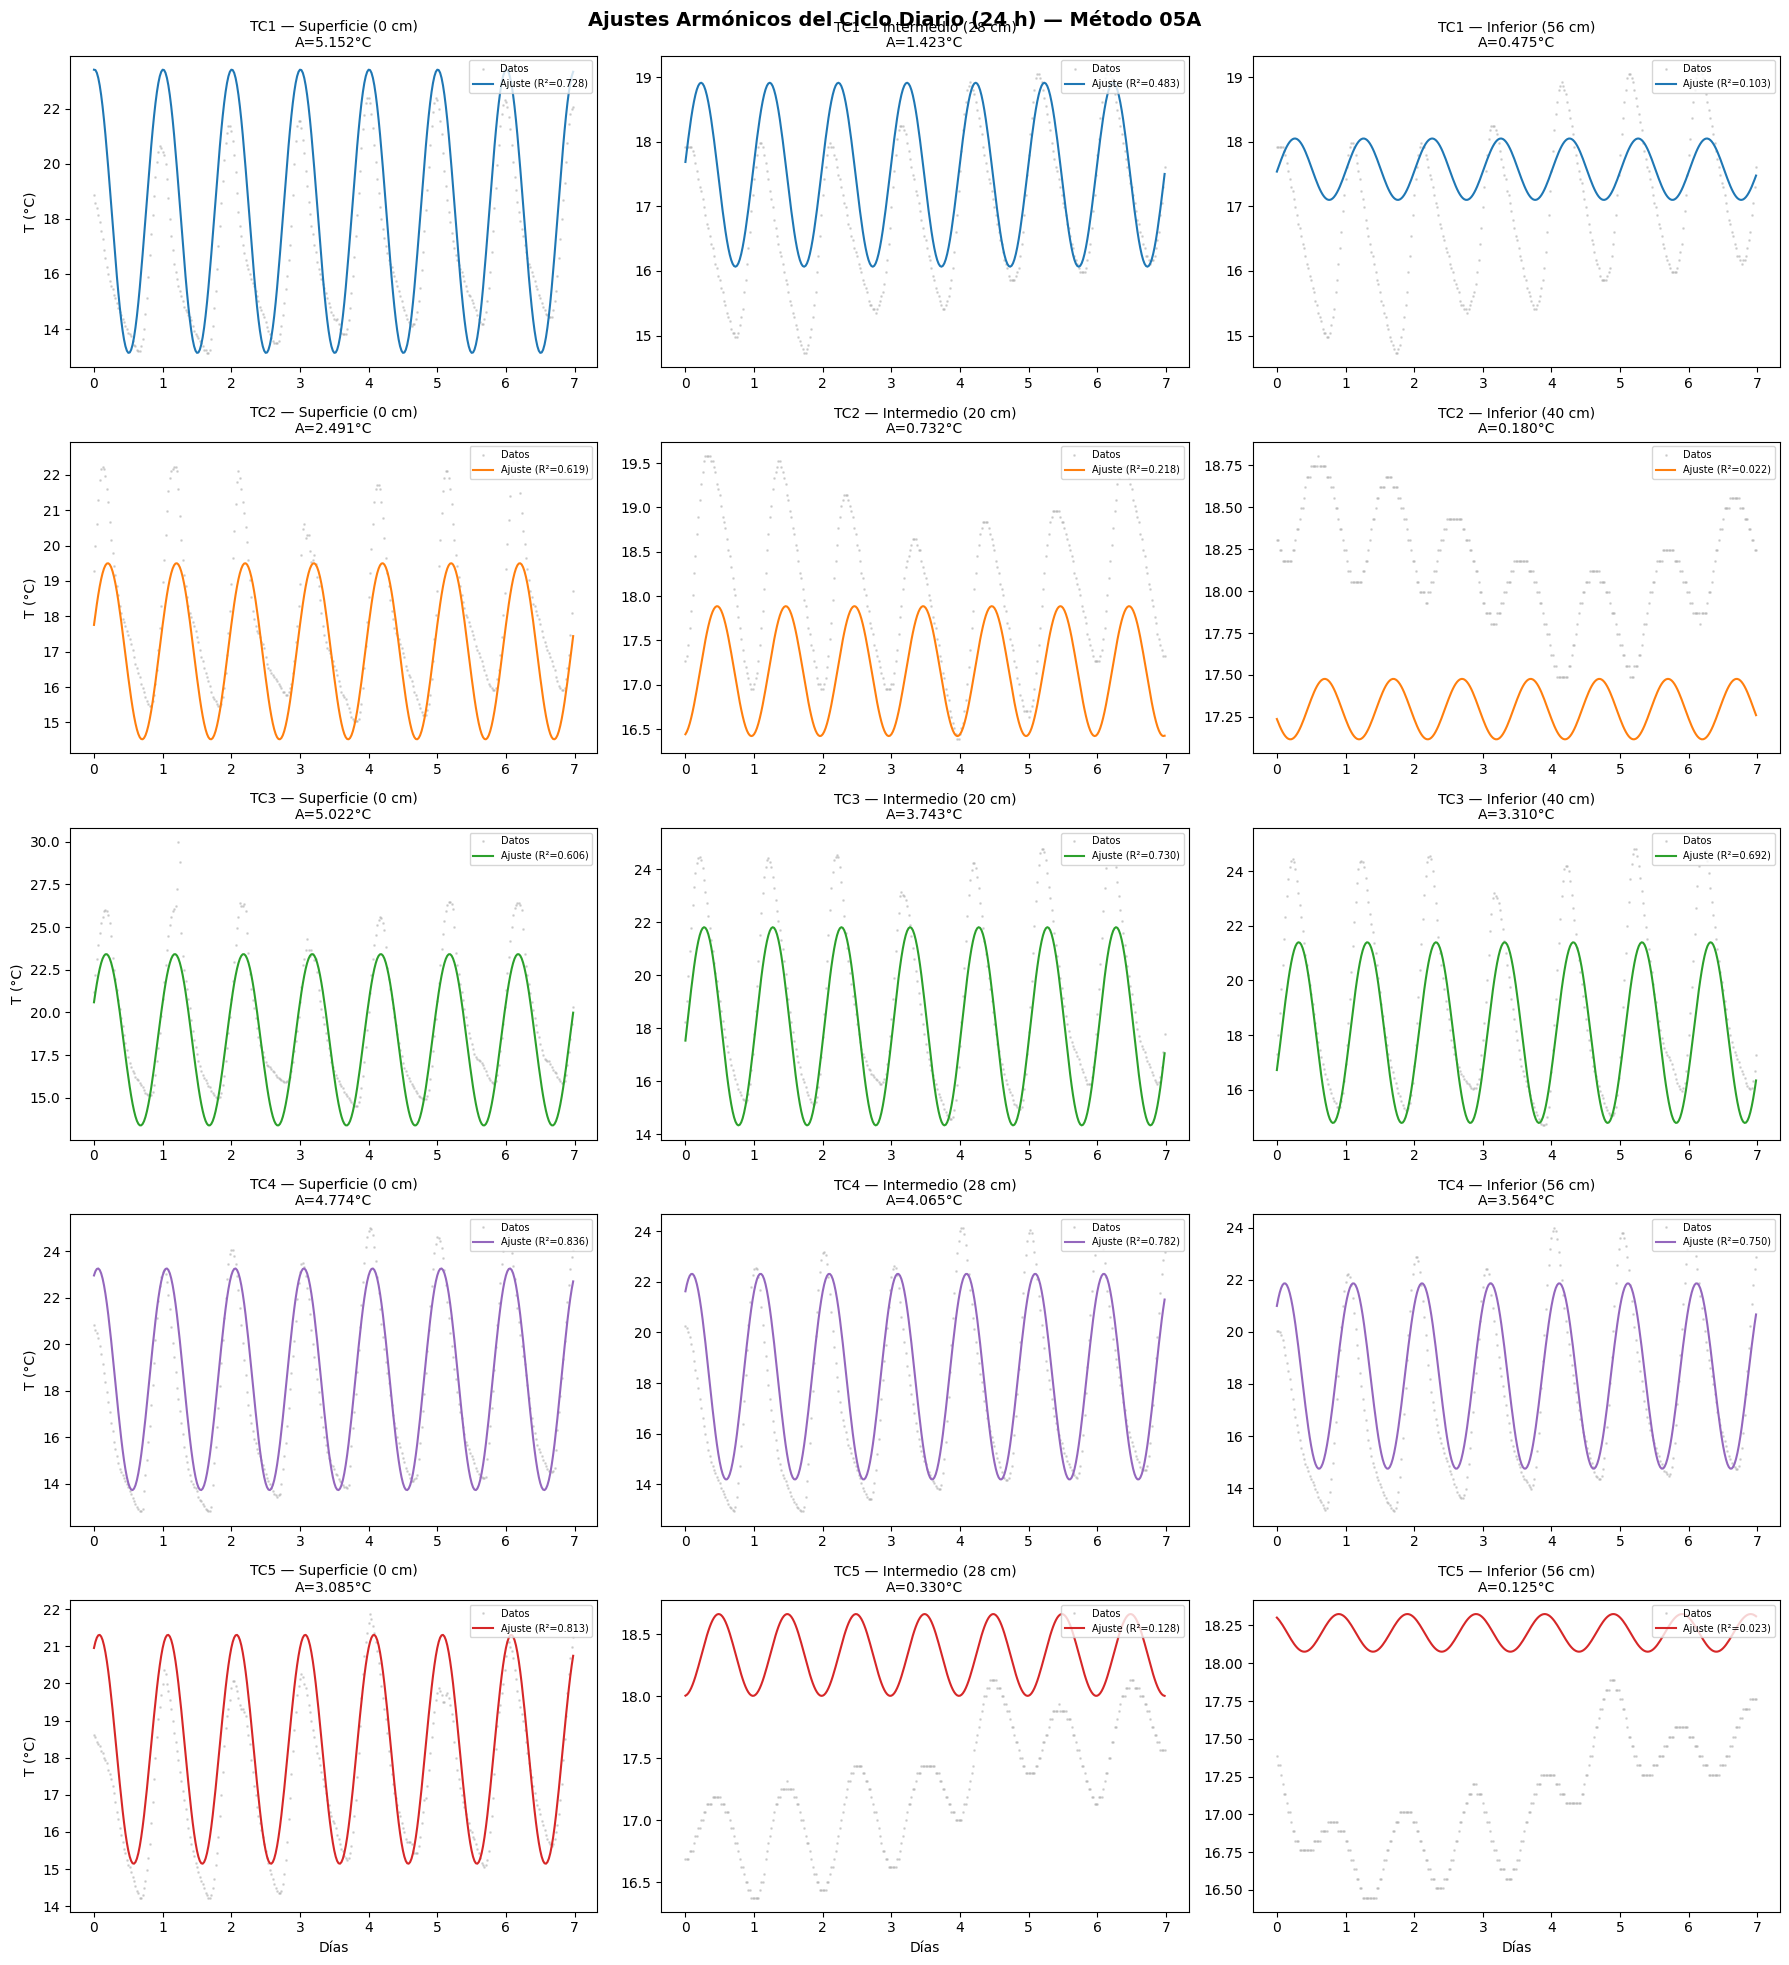

In [24]:
# ==========================================================================
# CELDA 6: Visualización de ajustes armónicos (primeros 7 días)
# ==========================================================================
fig, axes = plt.subplots(len(ACTIVE_TCS), 3, figsize=(18, 4*len(ACTIVE_TCS)))

for row_idx, tc_name in enumerate(ACTIVE_TCS):
    tc_map = TC_CONFIG[tc_name]
    for col_idx, (pos, pos_es) in enumerate([('surface', 'Superficie'),
                                              ('intermediate', 'Intermedio'),
                                              ('deep', 'Inferior')]):
        ax = axes[row_idx][col_idx]
        col = tc_map[pos]
        
        if col not in harmonic_results:
            ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes)
            continue
        
        result = harmonic_results[col]
        t_h = result['time_hours']
        
        # Recalcular serie original para este sensor
        tc_start = pd.Timestamp(TC_PERIODS[tc_name][0])
        tc_end = pd.Timestamp(TC_PERIODS[tc_name][1])
        mask_tc = (df_aligned['fecha'] >= tc_start) & (df_aligned['fecha'] <= tc_end)
        df_tc = df_aligned[mask_tc]
        series = df_tc[col].dropna().values
        
        # Primeros 7 días
        max_pts = min(len(t_h), 48 * 7)
        ax.plot(t_h[:max_pts] / 24, series[:max_pts], '.', color='#aaaaaa',
                alpha=0.4, markersize=2, label='Datos')
        ax.plot(t_h[:max_pts] / 24, result['fitted'][:max_pts], '-',
                color=TC_COLORS[tc_name], linewidth=1.5,
                label=f'Ajuste (R²={result["r_squared"]:.3f})')
        
        depth_cm = depths_m[col] * 100
        ax.set_title(f'{tc_name} — {pos_es} ({depth_cm:.0f} cm)\nA={result["amplitude"]:.3f}°C',
                     fontsize=10)
        ax.set_xlabel('Días' if row_idx == len(ACTIVE_TCS)-1 else '')
        ax.set_ylabel('T (°C)' if col_idx == 0 else '')
        ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Ajustes Armónicos del Ciclo Diario (24 h) — Método 05A', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(img_dir / 'ajustes_armonicos_05A.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Cálculo de Flujo: Hatch-Amplitude (Cabecera) + McCallum (Validación)

Se calculan flujos usando **parámetros térmicos de laboratorio IDIEM** específicos para cada TC.  
Solo se reportan y analizan **Hatch-Amplitude** y **McCallum**.

In [25]:
# ==========================================================================
# CELDA 7: Análisis de pares + Cálculo de flujo con parámetros IDIEM
# ==========================================================================

# Construir pares de sensores
pairs = []
for tc_name in ACTIVE_TCS:
    tc_map = TC_CONFIG[tc_name]
    s, m, d = tc_map['surface'], tc_map['intermediate'], tc_map['deep']
    dz_sm = abs(depths_m[m] - depths_m[s])
    dz_md = abs(depths_m[d] - depths_m[m])
    dz_sd = abs(depths_m[d] - depths_m[s])
    pairs.append((s, m, f'{tc_name}: sup-int', dz_sm, tc_name))
    pairs.append((m, d, f'{tc_name}: int-inf', dz_md, tc_name))
    pairs.append((s, d, f'{tc_name}: sup-inf', dz_sd, tc_name))

# Analizar pares y calcular flujos
print(f"{'='*110}")
print(f" FLUJO VERTICAL: Hatch-Amplitude (cabecera) + McCallum (validación) ".center(110))
print(f" Parámetros térmicos: LABORATORIO IDIEM (por TC) ".center(110))
print(f"{'='*110}")

all_flux_results = {}
pair_results = {}

for s_shallow, s_deep, pair_label, dz, tc_name in pairs:
    # Obtener datos para este par en su período
    tc_start = pd.Timestamp(TC_PERIODS[tc_name][0])
    tc_end = pd.Timestamp(TC_PERIODS[tc_name][1])
    mask_tc = (df_aligned['fecha'] >= tc_start) & (df_aligned['fecha'] <= tc_end)
    df_tc = df_aligned[mask_tc]
    
    mask = df_tc[s_shallow].notna() & df_tc[s_deep].notna()
    if mask.sum() < 48:
        print(f"  Par {pair_label}: DATOS INSUFICIENTES")
        continue
    
    t_start_tc = df_tc['fecha'].min()
    t_valid = ((df_tc['fecha'] - t_start_tc).dt.total_seconds() / 3600.0).values[mask]
    t1 = df_tc[s_shallow].values[mask]
    t2 = df_tc[s_deep].values[mask]
    
    params = analyze_sensor_pair(t_valid, t1, t2, period_hours=24.0)
    pair_results[pair_label] = {'params': params, 'dz': dz, 's_shallow': s_shallow, 's_deep': s_deep}
    
    # Usar parámetros térmicos IDIEM de esta TC
    tp = THERMAL_PARAMS_LAB[tc_name]
    
    flux_result = calculate_vflux_all_methods(
        amplitude_shallow=params['A_shallow'],
        amplitude_deep=params['A_deep'],
        phase_shallow=params['phi_shallow'],
        phase_deep=params['phi_deep'],
        depth_difference=dz,
        thermal_conductivity=tp['lambda_sediment'],
        heat_capacity_sediment=tp['C_sediment'],
        heat_capacity_water=tp['C_water'],
        angular_frequency=tp['omega']
    )
    all_flux_results[pair_label] = flux_result

print(f"\nCompletado: {len(all_flux_results)} pares analizados")

                      FLUJO VERTICAL: Hatch-Amplitude (cabecera) + McCallum (validación)                      
                               Parámetros térmicos: LABORATORIO IDIEM (por TC)                                
  Método                        m/s       mm/día
  --------------------------------------------
  mccallum                 3.19e-06       275.67
  hatch_amplitude          1.67e-06       143.87
  hatch_phase             -1.75e-05     -1512.41
  keery                    4.00e-06       345.76
  luce                     7.43e-06       642.06
  Método                        m/s       mm/día
  --------------------------------------------
  mccallum                 2.23e-06       193.07
  hatch_amplitude          1.42e-06       122.66
  hatch_phase             -2.29e-05     -1978.80
  keery                    4.63e-06       400.45
  luce                     6.84e-06       590.88
  Método                        m/s       mm/día
  --------------------------------------------


---
## 7. Tabla de Resultados — Hatch-Amplitude vs McCallum

**¿Por qué "Parámetros térmicos IDIEM por TC — Difusividad α medida (no calculada)"?**  
En la literatura estándar, la difusividad térmica α se calcula como α = λ / C_s. En este estudio,
IDIEM midió α directamente en laboratorio con el método de aguja caliente (Hot Disk), por lo que
**no depende** de errores compuestos de λ y C_s. Cada TC tiene su propio juego de parámetros
medidos, reflejando la heterogeneidad real del sedimento.

**Campos de la tabla por TC:**

| Campo | Descripción |
|-------|-------------|
| **Par** | Par de sensores utilizado: `sup-int` (superficie → intermedio), `int-inf` (intermedio → profundo), `sup-inf` (superficie → profundo) |
| **Hatch-Amp (mm/d)** | Flujo vertical estimado con el método Hatch-Amplitude, en mm/día. Método cabecera del estudio |
| **McCallum (mm/d)** | Flujo vertical estimado con el método McCallum, en mm/día. Usado como validación cruzada |
| **Hatch-Amp (m/s)** | Mismo flujo Hatch-Amplitude expresado en m/s (unidad SI, útil para modelación numérica) |
| **Diferencia %** | Diferencia relativa entre Hatch-Amp y McCallum: $\|HA - MC\| / \|HA\| \times 100$. Menor diferencia → mayor consistencia |

**Convención de signos:** (+) Infiltración: flujo descendente río → acuífero. (−) Exfiltración: flujo ascendente acuífero → río.

**Campos de la tabla resumen por TC:**

| Campo | Descripción |
|-------|-------------|
| **TC** | Termocupla (TC1–TC5) |
| **Hatch-Amp (mm/d)** | Media ± desviación estándar del flujo Hatch-Amplitude promediando los 3 pares |
| **McCallum (mm/d)** | Media ± desviación estándar del flujo McCallum promediando los 3 pares |
| **Diferencia** | Diferencia absoluta entre las medias de ambos métodos (mm/d) |
| **Dirección** | Infiltración ↓ si flujo medio > 0; Exfiltración ↑ si flujo medio < 0 |

In [26]:
# ==========================================================================
# CELDA 8: Tabla comparativa SOLO Hatch-Amp y McCallum
# ==========================================================================
MS_TO_MM_DAY = 86400.0 * 1000.0

results_data = []
for pair_name, flux_result in all_flux_results.items():
    tc_name = pair_name.split(':')[0].strip()
    pair_type = pair_name.split(':')[1].strip()
    
    for method, label in [('hatch_amplitude', 'Hatch-Amplitude'), ('mccallum', 'McCallum')]:
        v_mm = flux_result['flux_mm_day'].get(method, np.nan)
        v_ms = flux_result['flux_m_s'].get(method, np.nan)
        results_data.append({
            'TC': tc_name,
            'Par': pair_type,
            'Método': label,
            'q (mm/día)': round(v_mm, 2) if not np.isnan(v_mm) else np.nan,
            'q (m/s)': v_ms,  # Valor numérico real
            'Dirección': 'Infiltración ↓' if v_mm > 0 else ('Exfiltración ↑' if v_mm < 0 else '-'),
        })

df_results = pd.DataFrame(results_data)

# Asegurar q(m/s) como valor numérico
df_results['q (m/s)'] = pd.to_numeric(df_results['q (m/s)'], errors='coerce')

print(f"{'='*110}")
print(f" RESULTADOS: HATCH-AMPLITUDE (Cabecera) vs McCALLUM (Validación) ".center(110))
print(f" Parámetros térmicos IDIEM por TC — Difusividad α medida (no calculada) ".center(110))
print(f"{'='*110}")
print(f"  (+) Flujo positivo = Infiltración (río → acuífero)")
print(f"  (-) Flujo negativo = Exfiltración (acuífero → río)")
print()

# Tabla pivotada
for tc_name in ACTIVE_TCS:
    df_tc = df_results[df_results['TC'] == tc_name]
    tp = THERMAL_PARAMS_LAB[tc_name]
    print(f"\n{'─'*80}")
    print(f"  {tc_name} | λ={tp['lambda_sediment']:.3f} W/m·K | C={tp['C_sediment']/1e6:.3f} MJ/m³·K | α={tp['alpha_e']:.2e} m²/s")
    print(f"{'─'*80}")
    print(f"  {'Par':<12} {'Hatch-Amp (mm/d)':<20} {'McCallum (mm/d)':<20} {'Hatch-Amp (m/s)':<18} {'Diferencia %':<15}")
    print(f"  {'-'*75}")
    
    for pair_type in ['sup-int', 'int-inf', 'sup-inf']:
        df_pair = df_tc[df_tc['Par'] == pair_type]
        ha_row = df_pair[df_pair['Método'] == 'Hatch-Amplitude']
        mc_row = df_pair[df_pair['Método'] == 'McCallum']
        
        ha_mm = ha_row['q (mm/día)'].values[0] if len(ha_row) > 0 else np.nan
        mc_mm = mc_row['q (mm/día)'].values[0] if len(mc_row) > 0 else np.nan
        ha_ms = ha_row['q (m/s)'].values[0] if len(ha_row) > 0 else np.nan
        
        diff_pct = abs(ha_mm - mc_mm) / abs(ha_mm) * 100 if ha_mm != 0 and not np.isnan(ha_mm) and not np.isnan(mc_mm) else np.nan
        
        ha_ms_str = f"{ha_ms:.2e}" if not np.isnan(ha_ms) else 'NaN'
        diff_str = f"{diff_pct:.1f}%" if not np.isnan(diff_pct) else '-'
        
        print(f"  {pair_type:<12} {ha_mm:<20.2f} {mc_mm:<20.2f} {ha_ms_str:<18} {diff_str:<15}")

# Resumen por TC (promedio Hatch-Amp de todos los pares)
print(f"\n{'='*110}")
print(f" FLUJO PROMEDIO POR TC (promediando todos los pares) ".center(110))
print(f"{'='*110}")
print(f"  {'TC':<8} {'Hatch-Amp (mm/d)':<20} {'McCallum (mm/d)':<20} {'Diferencia':<15} {'Dirección':<20}")
print(f"  {'-'*80}")

flujos_promedio_tc = {}
for tc_name in ACTIVE_TCS:
    df_tc = df_results[df_results['TC'] == tc_name]
    ha_vals = df_tc[df_tc['Método'] == 'Hatch-Amplitude']['q (mm/día)'].dropna()
    mc_vals = df_tc[df_tc['Método'] == 'McCallum']['q (mm/día)'].dropna()
    
    ha_mean = ha_vals.mean() if len(ha_vals) > 0 else np.nan
    ha_std = ha_vals.std() if len(ha_vals) > 1 else 0
    mc_mean = mc_vals.mean() if len(mc_vals) > 0 else np.nan
    mc_std = mc_vals.std() if len(mc_vals) > 1 else 0
    
    diff = abs(ha_mean - mc_mean) if not np.isnan(ha_mean) and not np.isnan(mc_mean) else np.nan
    dir_str = 'Infiltración ↓' if ha_mean > 0 else 'Exfiltración ↑'
    
    flujos_promedio_tc[tc_name] = {'hatch_mean': ha_mean, 'hatch_std': ha_std,
                                    'mc_mean': mc_mean, 'mc_std': mc_std}
    
    print(f"  {tc_name:<8} {ha_mean:>7.1f} ± {ha_std:<8.1f}    {mc_mean:>7.1f} ± {mc_std:<8.1f}    "
          f"{diff:<15.1f} {dir_str:<20}")

# Promedio global
all_ha = df_results[df_results['Método'] == 'Hatch-Amplitude']['q (mm/día)'].dropna()
all_mc = df_results[df_results['Método'] == 'McCallum']['q (mm/día)'].dropna()
print(f"  {'─'*80}")
print(f"  {'GLOBAL':<8} {all_ha.mean():>7.1f} ± {all_ha.std():<8.1f}    {all_mc.mean():>7.1f} ± {all_mc.std():<8.1f}")

                       RESULTADOS: HATCH-AMPLITUDE (Cabecera) vs McCALLUM (Validación)                        
                    Parámetros térmicos IDIEM por TC — Difusividad α medida (no calculada)                    
  (+) Flujo positivo = Infiltración (río → acuífero)
  (-) Flujo negativo = Exfiltración (acuífero → río)


────────────────────────────────────────────────────────────────────────────────
  TC1 | λ=0.614 W/m·K | C=3.389 MJ/m³·K | α=2.03e-07 m²/s
────────────────────────────────────────────────────────────────────────────────
  Par          Hatch-Amp (mm/d)     McCallum (mm/d)      Hatch-Amp (m/s)    Diferencia %   
  ---------------------------------------------------------------------------
  sup-int      143.87               275.67               1.67e-06           91.6%          
  int-inf      122.66               193.07               1.42e-06           57.4%          
  sup-inf      133.26               984.68               1.54e-06           638.9%         

───

---
## 8. Visualizaciones

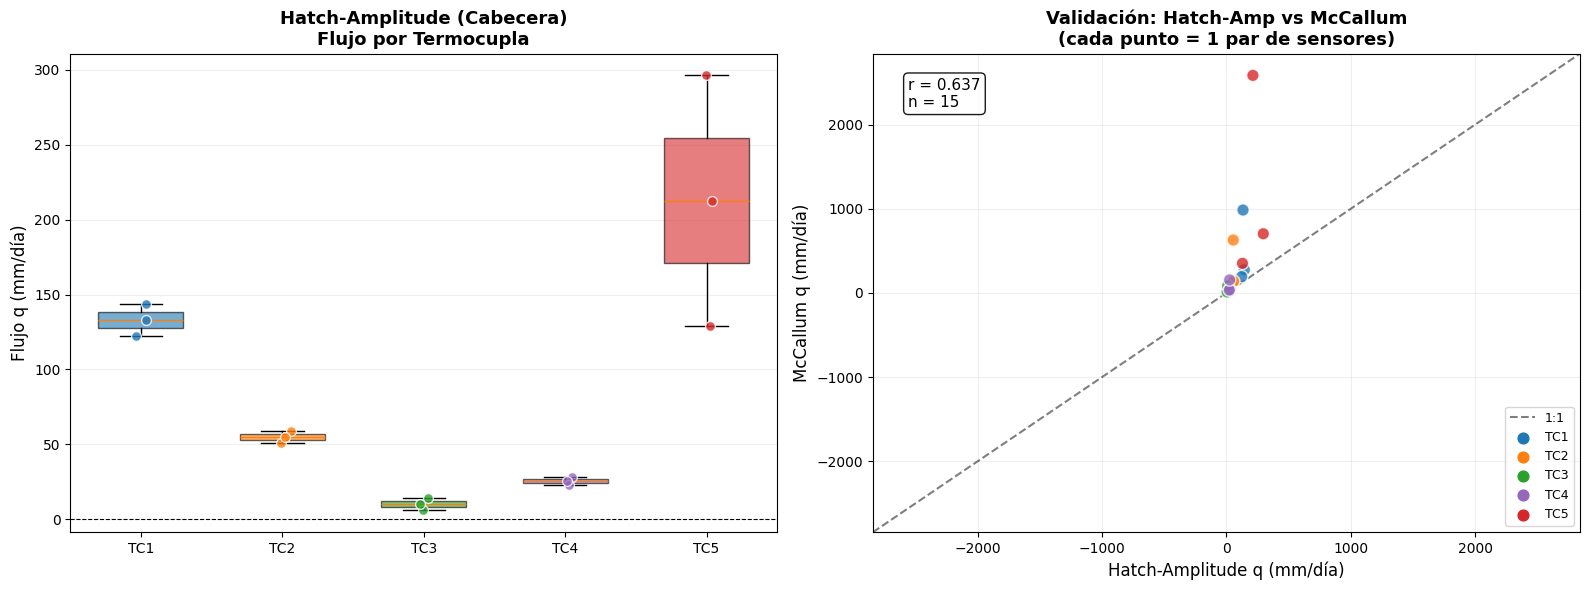


MÉTRICAS DE VALIDACIÓN Hatch-Amp vs McCallum:
  Correlación r: 0.637
  RMSE: 680.61 mm/día
  Sesgo (McCallum - Hatch): 335.09 mm/día


In [27]:
# ==========================================================================
# CELDA 9: Boxplot para Hatch-Amplitude (por TC)
# ==========================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel 1: Boxplot Hatch-Amplitude por TC ---
ax1 = axes[0]
data_ha = []
labels_ha = []
colors_bp = []
for tc_name in ACTIVE_TCS:
    tc_pairs = {k: v for k, v in all_flux_results.items() if tc_name in k}
    vals = [v['flux_mm_day'].get('hatch_amplitude', np.nan) for v in tc_pairs.values()]
    vals = [x for x in vals if not np.isnan(x)]
    data_ha.append(vals)
    labels_ha.append(tc_name)
    colors_bp.append(TC_COLORS[tc_name])

bp1 = ax1.boxplot(data_ha, tick_labels=labels_ha, patch_artist=True, widths=0.6)
for patch, color in zip(bp1['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Superponer puntos individuales
for i, vals in enumerate(data_ha):
    x = np.random.normal(i+1, 0.04, size=len(vals))
    ax1.scatter(x, vals, color=colors_bp[i], alpha=0.8, s=50, zorder=5, edgecolors='white')

ax1.axhline(y=0, color='k', linestyle='--', linewidth=0.8)
ax1.set_ylabel('Flujo q (mm/día)', fontsize=12)
ax1.set_title('Hatch-Amplitude (Cabecera)\nFlujo por Termocupla', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.2, axis='y')

# --- Panel 2: Comparación Hatch vs McCallum ---
ax2 = axes[1]
data_mc = []
for tc_name in ACTIVE_TCS:
    tc_pairs = {k: v for k, v in all_flux_results.items() if tc_name in k}
    vals = [v['flux_mm_day'].get('mccallum', np.nan) for v in tc_pairs.values()]
    vals = [x for x in vals if not np.isnan(x)]
    data_mc.append(vals)

# Scatter Hatch vs McCallum
all_ha_vals = []
all_mc_vals = []
all_colors = []
for i, tc_name in enumerate(ACTIVE_TCS):
    tc_pairs = {k: v for k, v in all_flux_results.items() if tc_name in k}
    for pair_name, fr in tc_pairs.items():
        ha = fr['flux_mm_day'].get('hatch_amplitude', np.nan)
        mc = fr['flux_mm_day'].get('mccallum', np.nan)
        if not np.isnan(ha) and not np.isnan(mc):
            all_ha_vals.append(ha)
            all_mc_vals.append(mc)
            all_colors.append(TC_COLORS[tc_name])

ax2.scatter(all_ha_vals, all_mc_vals, c=all_colors, s=80, alpha=0.8,
            edgecolors='white', linewidth=1, zorder=5)

# Línea 1:1
lim_vals = all_ha_vals + all_mc_vals
if lim_vals:
    lim = max(abs(min(lim_vals)), abs(max(lim_vals))) * 1.1
    ax2.plot([-lim, lim], [-lim, lim], 'k--', alpha=0.5, label='1:1')
    ax2.set_xlim(-lim, lim)
    ax2.set_ylim(-lim, lim)

# Correlación
if len(all_ha_vals) > 2:
    corr = np.corrcoef(all_ha_vals, all_mc_vals)[0, 1]
    ax2.text(0.05, 0.95, f'r = {corr:.3f}\nn = {len(all_ha_vals)}',
             transform=ax2.transAxes, fontsize=11, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Leyenda por TC
for tc_name in ACTIVE_TCS:
    ax2.scatter([], [], color=TC_COLORS[tc_name], s=60, label=tc_name)
ax2.legend(fontsize=9, loc='lower right')

ax2.set_xlabel('Hatch-Amplitude q (mm/día)', fontsize=12)
ax2.set_ylabel('McCallum q (mm/día)', fontsize=12)
ax2.set_title('Validación: Hatch-Amp vs McCallum\n(cada punto = 1 par de sensores)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(str(img_dir / 'boxplot_hatch_05A.png'), dpi=150, bbox_inches='tight')
plt.show()

if len(all_ha_vals) > 2:
    rmse = np.sqrt(np.mean((np.array(all_ha_vals) - np.array(all_mc_vals))**2))
    bias = np.mean(np.array(all_mc_vals) - np.array(all_ha_vals))
    print(f"\nMÉTRICAS DE VALIDACIÓN Hatch-Amp vs McCallum:")
    print(f"  Correlación r: {corr:.3f}")
    print(f"  RMSE: {rmse:.2f} mm/día")
    print(f"  Sesgo (McCallum - Hatch): {bias:.2f} mm/día")

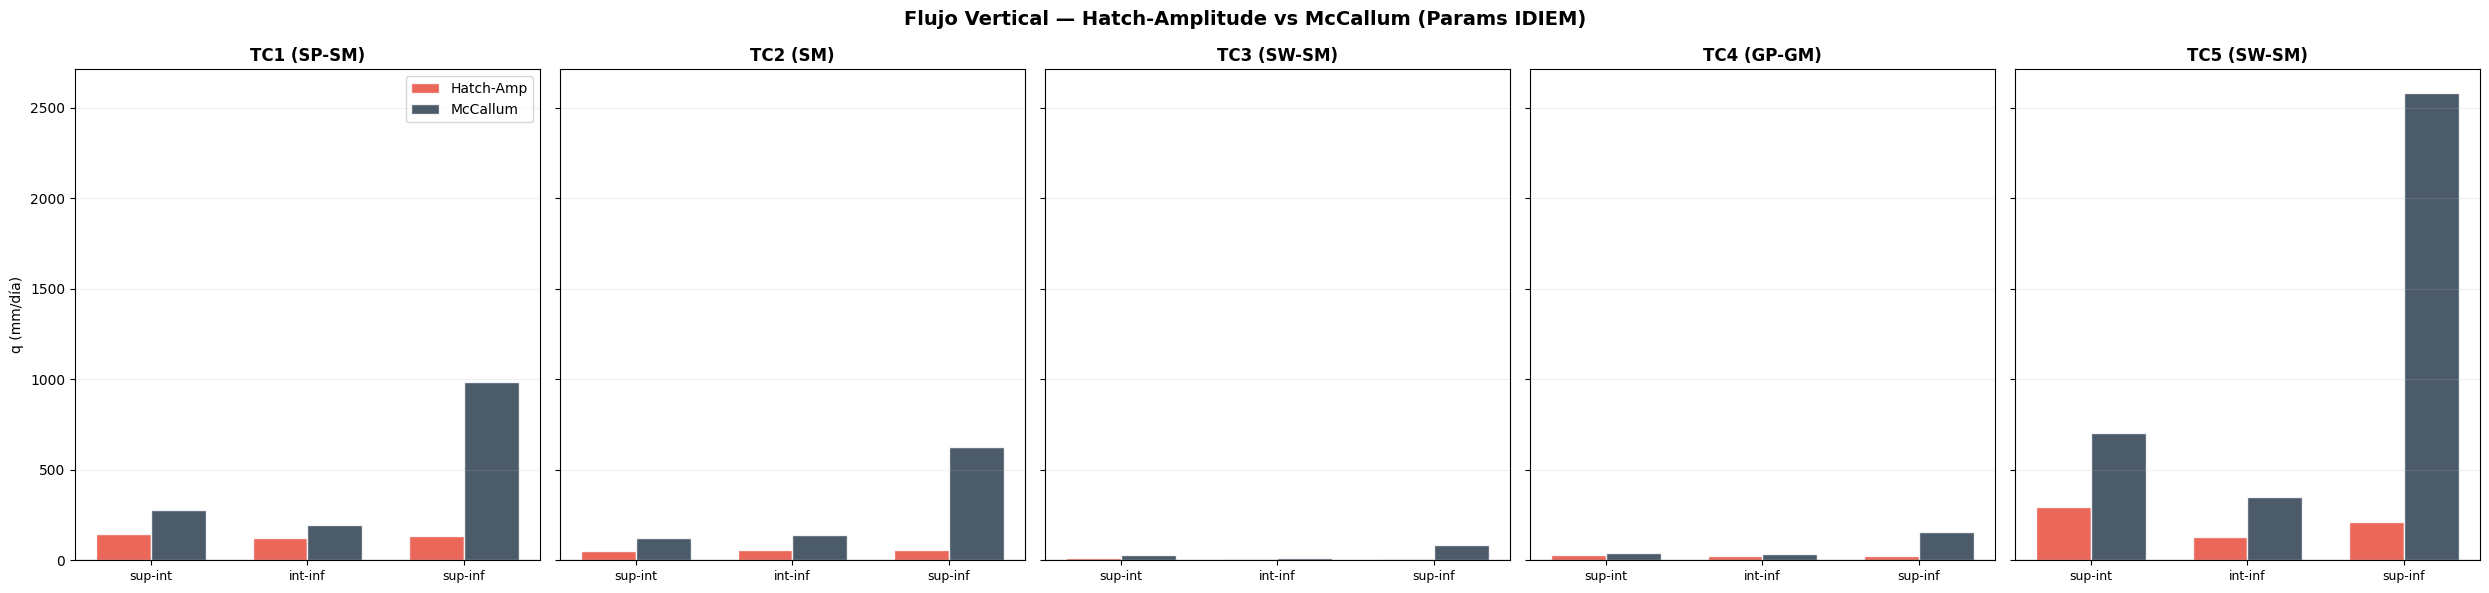

In [28]:
# ==========================================================================
# CELDA 10: Barras de flujo por TC (solo Hatch-Amp + McCallum)
# ==========================================================================
fig, axes = plt.subplots(1, len(ACTIVE_TCS), figsize=(5*len(ACTIVE_TCS), 6), sharey=True)

method_colors = {'hatch_amplitude': '#e74c3c', 'mccallum': '#2c3e50'}
method_names = {'hatch_amplitude': 'Hatch-Amp', 'mccallum': 'McCallum'}

for ax_idx, tc_name in enumerate(ACTIVE_TCS):
    ax = axes[ax_idx]
    tc_pairs = {k: v for k, v in all_flux_results.items() if tc_name in k}
    pair_names = list(tc_pairs.keys())
    x = np.arange(len(pair_names))
    width = 0.35
    
    for i, (method, name) in enumerate([('hatch_amplitude', 'Hatch-Amp'), ('mccallum', 'McCallum')]):
        vals = [tc_pairs[p]['flux_mm_day'].get(method, 0) for p in pair_names]
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=name,
                      color=method_colors[method], alpha=0.85, edgecolor='white')
    
    short_names = [p.replace(f'{tc_name}: ', '') for p in pair_names]
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, fontsize=9)
    tp = THERMAL_PARAMS_LAB[tc_name]
    ax.set_title(f'{tc_name} ({tp["USCS"]})', fontsize=12, fontweight='bold')
    ax.set_ylabel('q (mm/día)' if ax_idx == 0 else '')
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
    ax.grid(True, alpha=0.2, axis='y')

axes[0].legend(fontsize=10)
plt.suptitle('Flujo Vertical — Hatch-Amplitude vs McCallum (Params IDIEM)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(img_dir / 'barras_hatch_mccallum_05A.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Series Temporales de Flujo (Ventanas Deslizantes)

Cálculo de series temporales de flujo vertical usando ventanas móviles de 48h con paso de 12h,  
con parámetros térmicos de laboratorio IDIEM.

  Método                        m/s       mm/día
  --------------------------------------------
  mccallum                 1.22e-05      1056.00
  hatch_amplitude          2.61e-05      2258.62
  hatch_phase             -1.69e-05     -1458.34
  keery                    1.62e-05      1395.57
  luce                          NaN          NaN
  Método                        m/s       mm/día
  --------------------------------------------
  mccallum                 1.22e-05      1051.73
  hatch_amplitude          2.43e-05      2096.26
  hatch_phase             -1.68e-05     -1453.24
  keery                    1.52e-05      1313.68
  luce                          NaN          NaN
  Método                        m/s       mm/día
  --------------------------------------------
  mccallum                 1.25e-05      1081.55
  hatch_amplitude          2.57e-05      2219.90
  hatch_phase             -2.16e-06      -186.57
  keery                    1.39e-05      1198.16
  luce                    

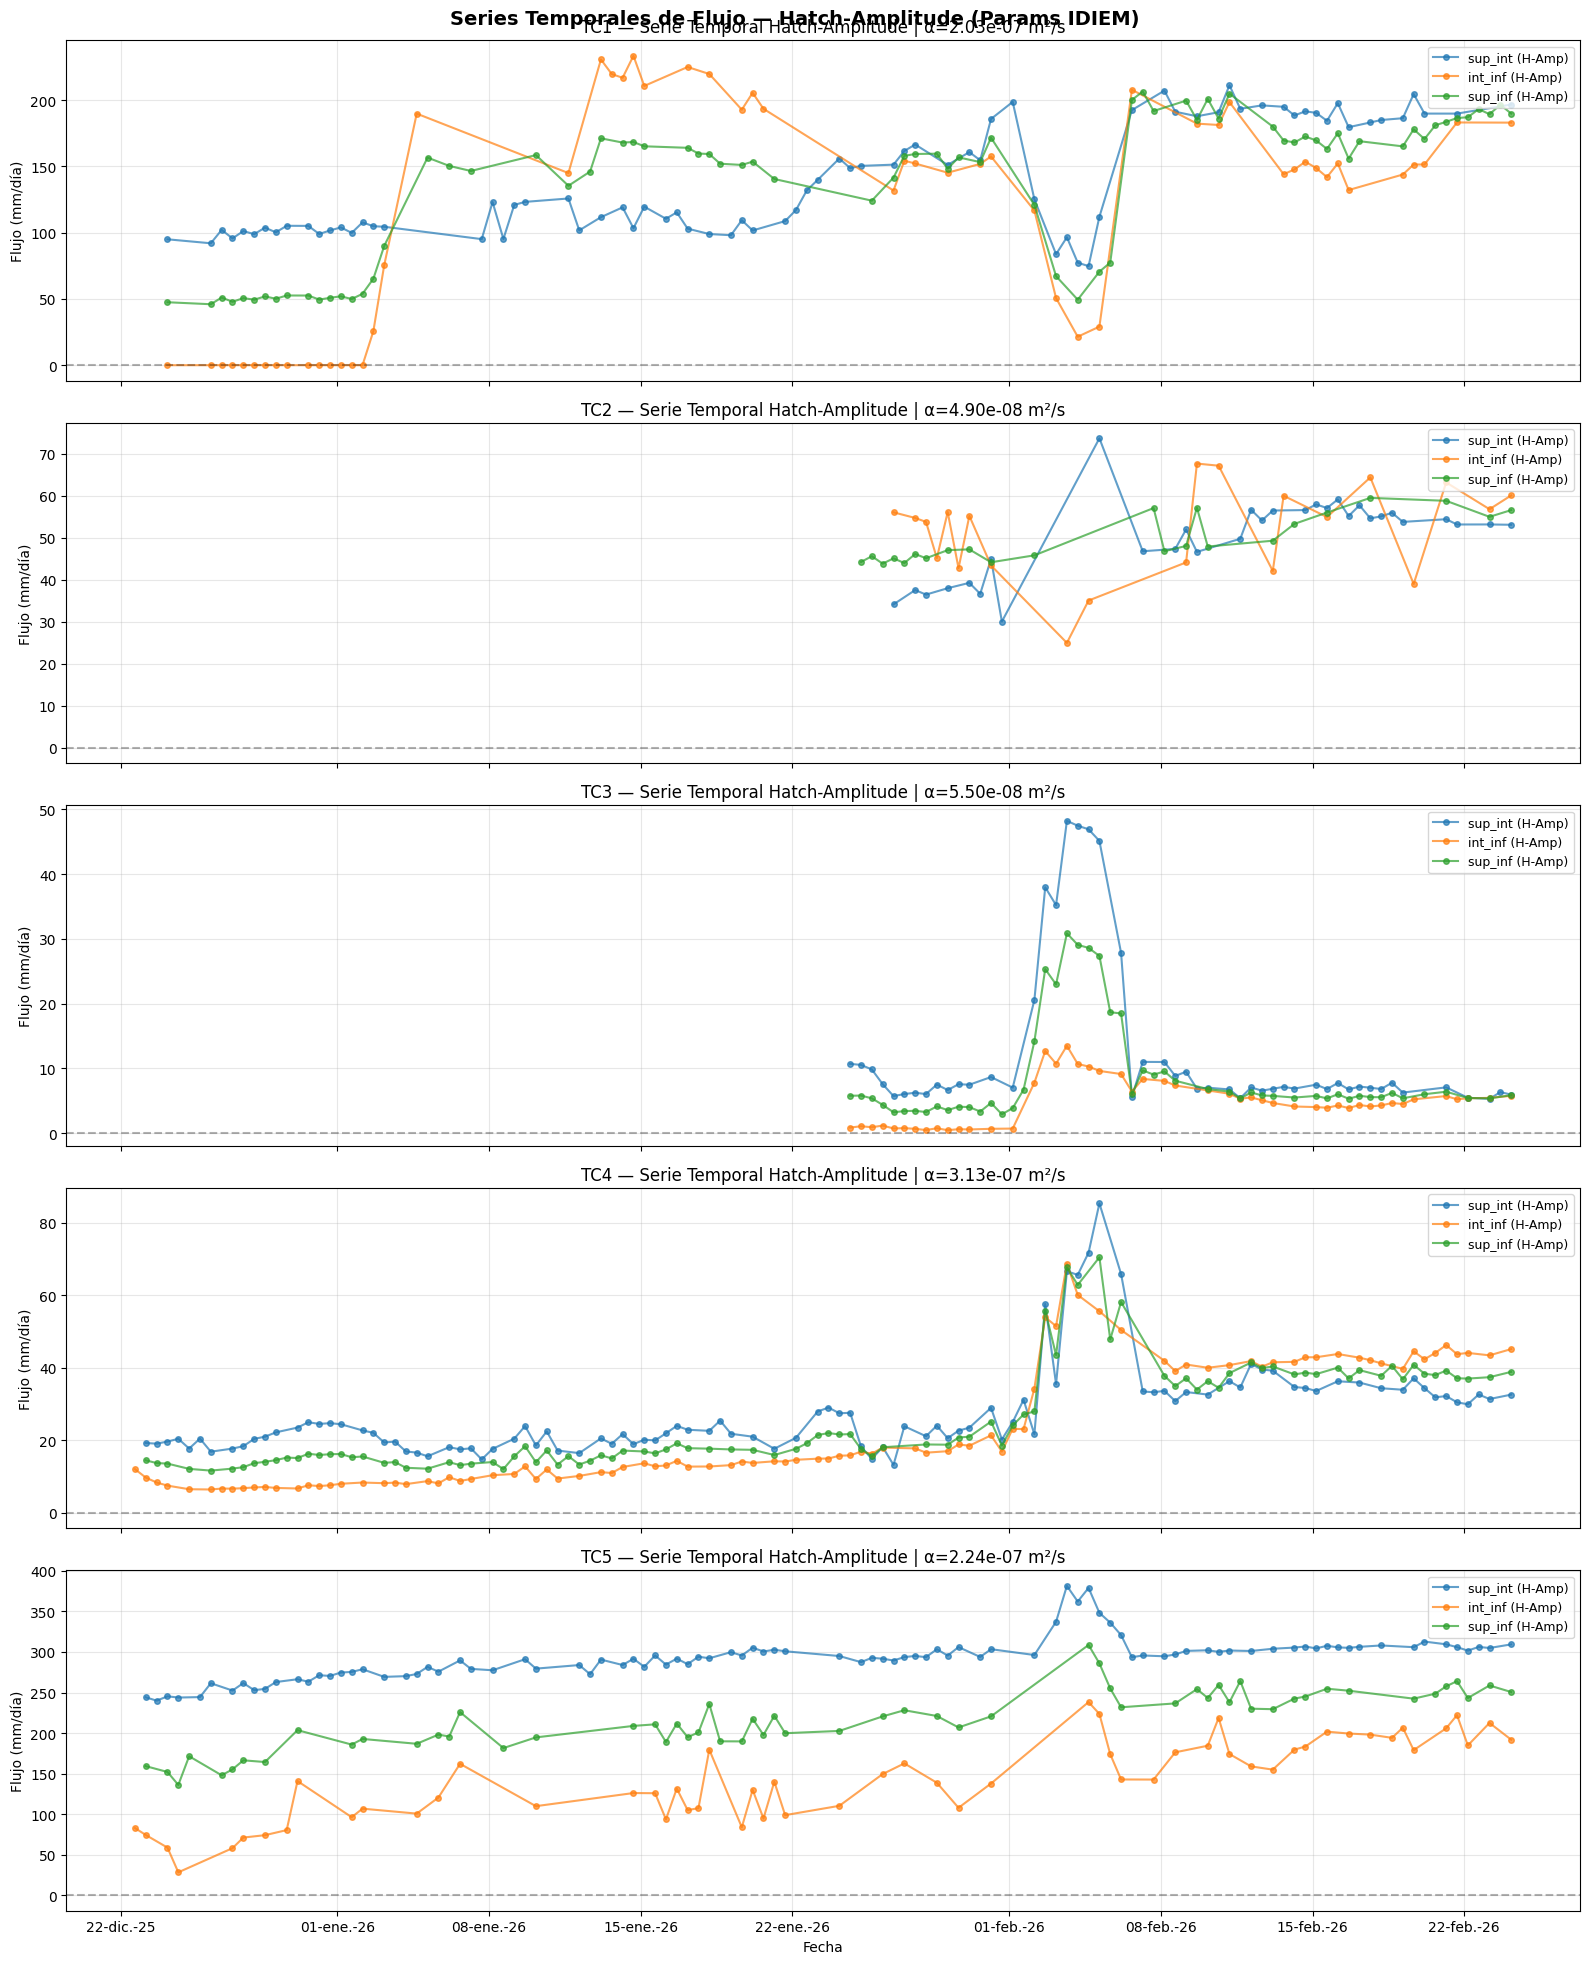

✔ Series temporales exportadas a: resultados_python\terreno_2026_hatch\series_temporales


In [29]:
# ==========================================================================
# CELDA 11: Series temporales con ventanas deslizantes (params IDIEM)
# ==========================================================================
WINDOW_HOURS = 48
STEP_HOURS = 12

# Construir pares para batch
sensor_pairs = []
for tc_name in ACTIVE_TCS:
    config = TC_CONFIG[tc_name]
    for pair_type, (sh, dp) in [('sup_int', ('surface', 'intermediate')),
                                 ('int_inf', ('intermediate', 'deep')),
                                 ('sup_inf', ('surface', 'deep'))]:
        sensor_pairs.append({
            'name': f'{tc_name}_{pair_type}',
            'shallow': config[sh],
            'deep': config[dp],
            'depth_shallow': depths_m[config[sh]],
            'depth_deep': depths_m[config[dp]],
        })

# Crear directorio de series temporales
output_ts_dir = out_dir / 'series_temporales'
output_ts_dir.mkdir(parents=True, exist_ok=True)

# Calcular series para cada TC con SUS parámetros térmicos
flux_ts_results = {}
for pair in sensor_pairs:
    tc_name = pair['name'].split('_')[0]
    tp = THERMAL_PARAMS_LAB[tc_name]
    
    # Usar thermal_params con alpha overridden por valor medido
    tp_for_calc = {
        'lambda_sediment': tp['lambda_sediment'],
        'C_sediment': tp['C_sediment'],
        'C_water': tp['C_water'],
        'omega': tp['omega'],
    }
    
    df_flux = calculate_flux_timeseries(
        time_array=df_aligned['fecha'],
        temp_shallow=df_aligned[pair['shallow']].values,
        temp_deep=df_aligned[pair['deep']].values,
        depth_shallow=pair['depth_shallow'],
        depth_deep=pair['depth_deep'],
        thermal_params=tp_for_calc,
        window_hours=WINDOW_HOURS,
        step_hours=STEP_HOURS
    )
    
    if df_flux is not None and len(df_flux) > 0:
        flux_ts_results[pair['name']] = df_flux
        df_flux.to_csv(output_ts_dir / f"flujo_temporal_{pair['name']}.csv", index=False)

# Visualización
fig, axes = plt.subplots(len(ACTIVE_TCS), 1, figsize=(16, 4*len(ACTIVE_TCS)), sharex=True)
colors_pt = {'sup_int': '#1f77b4', 'int_inf': '#ff7f0e', 'sup_inf': '#2ca02c'}

for ax, tc_name in zip(axes, ACTIVE_TCS):
    for pair_name, df_flux in flux_ts_results.items():
        if tc_name not in pair_name:
            continue
        df_valid = df_flux[df_flux['quality_flag'] == 0]
        if len(df_valid) == 0:
            continue
        
        for pt in ['sup_int', 'int_inf', 'sup_inf']:
            if pt in pair_name:
                color = colors_pt[pt]
                break
        
        if 'flux_hatch_amplitude_mm_day' in df_valid.columns:
            ax.plot(df_valid['datetime'], df_valid['flux_hatch_amplitude_mm_day'],
                   'o-', color=color, alpha=0.7, markersize=4,
                   label=f'{pair_name.split("_", 1)[1]} (H-Amp)')
    
    tp = THERMAL_PARAMS_LAB[tc_name]
    ax.set_ylabel('Flujo (mm/día)')
    ax.set_title(f'{tc_name} — Serie Temporal Hatch-Amplitude | α={tp["alpha_e"]:.2e} m²/s')
    ax.legend(loc='upper right', fontsize=9)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter(DATE_FMT))

axes[-1].set_xlabel('Fecha')
plt.suptitle('Series Temporales de Flujo — Hatch-Amplitude (Params IDIEM)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(img_dir / 'series_temporales_hatch_05A.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✔ Series temporales exportadas a: {output_ts_dir.relative_to(project_root)}")

---
## 10. Métricas de Confiabilidad — Enfocadas en Hatch-Amp y McCallum

El **Índice de Confiabilidad (IC)** es un indicador compuesto (0–1) que pondera múltiples criterios
para evaluar la calidad de cada estimación de flujo. Los pesos se asignan según la importancia
relativa para el enfoque Hatch-Amplitude + McCallum.

**Campos de la tabla:**

| Campo | Descripción | Peso en IC |
|-------|-------------|:----------:|
| **TC** | Termocupla (TC1–TC5) | — |
| **Par** | Par de sensores: `sup→int`, `int→inf`, `sup→inf` | — |
| **IC_total** | Índice de confiabilidad total (promedio ponderado, 0–1). Más alto = más confiable | — |
| **R2_sup** | R² del ajuste armónico del sensor superior. Mide calidad de la señal térmica superficial | 25% |
| **R2_inf** | R² del ajuste armónico del sensor inferior. Mide calidad de la señal térmica profunda | 20% |
| **Concord_HA_MC** | Concordancia entre Hatch-Amplitude y McCallum: $1 - \|HA - MC\| / \max(\|HA\|, \|MC\|)$. Si ambos métodos coinciden → cercano a 1 | 25% |
| **IC_lit** | Consistencia con rango de literatura (10–600 mm/d para ríos aluviales). Valor 1.0 si el flujo cae dentro del rango esperado | 15% |
| **IC_physics** | Consistencia física: verifica que la amplitud térmica decrezca con la profundidad (como se espera por difusión). 1.0 si se cumple, 0.5 si no | 15% |
| **HA_mm_d** | Flujo Hatch-Amplitude del par (mm/d) — valor de referencia para los criterios | — |
| **MC_mm_d** | Flujo McCallum del par (mm/d) — valor de comparación para concordancia | — |

In [30]:
# ==========================================================================
# CELDA 12: Índice de Confiabilidad enfocado Hatch-Amp + McCallum
# ==========================================================================

# Pesos ajustados para enfoque Hatch-Amp/McCallum
WEIGHTS = {
    'R2_sup': 0.25,           # R² sensor superior
    'R2_inf': 0.20,           # R² sensor inferior
    'concordancia_HA_MC': 0.25,  # Acuerdo entre Hatch-Amp y McCallum
    'lit_range': 0.15,        # Rango de literatura
    'physics': 0.15,          # Consistencia física (amplitud decrece)
}

LIT_RANGE_MM_DAY = (10, 600)  # Rango amplio para ríos aluviales

PAIR_MAP = {'sup_int': ('surface', 'intermediate'),
            'int_inf': ('intermediate', 'deep'),
            'sup_inf': ('surface', 'deep')}

print('=' * 100)
print(' MÉTRICAS DE CONFIABILIDAD — Hatch-Amplitude (Cabecera) + McCallum (Validación) '.center(100))
print('=' * 100)

ic_results = {}
ic_rows = []

for tc_name in ACTIVE_TCS:
    tc_map = TC_CONFIG[tc_name]
    ic_results[tc_name] = {}
    
    for pair_name, (pos_sh, pos_dp) in PAIR_MAP.items():
        pair_key = f"{tc_name}: {pair_name.replace('_', '-')}"
        if pair_key not in all_flux_results:
            continue
        
        shallow = tc_map[pos_sh]
        deep_s = tc_map[pos_dp]
        
        # R² de ajustes
        r2_sup = harmonic_results.get(shallow, {}).get('r_squared', 0)
        r2_inf = harmonic_results.get(deep_s, {}).get('r_squared', 0)
        
        # Flujos
        fr = all_flux_results[pair_key]
        ha_val = fr['flux_mm_day'].get('hatch_amplitude', np.nan)
        mc_val = fr['flux_mm_day'].get('mccallum', np.nan)
        
        # IC: R² (normalizado)
        ic_r2_sup = min(r2_sup, 1.0)
        ic_r2_inf = min(r2_inf, 1.0)
        
        # IC: Concordancia Hatch vs McCallum
        if not np.isnan(ha_val) and not np.isnan(mc_val) and ha_val != 0:
            diff_rel = abs(ha_val - mc_val) / max(abs(ha_val), abs(mc_val))
            ic_concord = max(0, 1 - diff_rel)
        else:
            ic_concord = 0.5
        
        # IC: Rango literatura
        flux_ref = ha_val if not np.isnan(ha_val) else 0
        if LIT_RANGE_MM_DAY[0] <= abs(flux_ref) <= LIT_RANGE_MM_DAY[1]:
            ic_lit = 1.0
        elif abs(flux_ref) > 0:
            if abs(flux_ref) < LIT_RANGE_MM_DAY[0]:
                ic_lit = abs(flux_ref) / LIT_RANGE_MM_DAY[0]
            else:
                ic_lit = max(0, 1 - (abs(flux_ref) - LIT_RANGE_MM_DAY[1]) / LIT_RANGE_MM_DAY[1])
        else:
            ic_lit = 0
        
        # IC: Física (amplitud decrece)
        amp_sup = harmonic_results.get(shallow, {}).get('amplitude', 0)
        amp_inf = harmonic_results.get(deep_s, {}).get('amplitude', 0)
        ic_physics = 1.0 if amp_sup > amp_inf else 0.5
        
        # IC total
        IC = (WEIGHTS['R2_sup'] * ic_r2_sup +
              WEIGHTS['R2_inf'] * ic_r2_inf +
              WEIGHTS['concordancia_HA_MC'] * ic_concord +
              WEIGHTS['lit_range'] * ic_lit +
              WEIGHTS['physics'] * ic_physics)
        
        ic_data = {
            'IC_total': round(IC, 3), 'R2_sup': round(r2_sup, 3), 'R2_inf': round(r2_inf, 3),
            'Concord_HA_MC': round(ic_concord, 3), 'IC_lit': round(ic_lit, 3),
            'IC_physics': round(ic_physics, 3), 'HA_mm_d': round(ha_val, 1) if not np.isnan(ha_val) else 0,
            'MC_mm_d': round(mc_val, 1) if not np.isnan(mc_val) else 0,
        }
        ic_results[tc_name][pair_name] = ic_data
        ic_rows.append({'TC': tc_name, 'Par': pair_name.replace('_', '→'), **ic_data})

df_ic = pd.DataFrame(ic_rows)
print()
print(df_ic.to_string(index=False))

# Clasificación
print(f"\n{'─'*80}")
print("CLASIFICACIÓN:")
print("  IC ≥ 0.85: ●●●● Alta confiabilidad")
print("  IC ≥ 0.70: ●●●○ Buena confiabilidad")
print("  IC ≥ 0.50: ●●○○ Moderada")
print("  IC < 0.50: ●○○○ Baja (validar con datos independientes)")

           MÉTRICAS DE CONFIABILIDAD — Hatch-Amplitude (Cabecera) + McCallum (Validación)           

 TC     Par  IC_total  R2_sup  R2_inf  Concord_HA_MC  IC_lit  IC_physics  HA_mm_d  MC_mm_d
TC1 sup→int     0.709   0.728   0.483          0.522   1.000         1.0    143.9    275.7
TC1 int→inf     0.600   0.483   0.103          0.635   1.000         1.0    122.7    193.1
TC1 sup→inf     0.536   0.728   0.103          0.135   1.000         1.0    133.3    984.7
TC2 sup→int     0.600   0.619   0.218          0.408   1.000         1.0     51.2    125.4
TC2 int→inf     0.465   0.218   0.022          0.425   1.000         1.0     58.6    138.0
TC2 sup→inf     0.481   0.619   0.022          0.087   1.000         1.0     54.9    628.3
TC3 sup→int     0.722   0.606   0.730          0.496   1.000         1.0     13.8     27.9
TC3 int→inf     0.688   0.730   0.692          0.523   0.579         1.0      5.8     11.1
TC3 sup→inf     0.617   0.606   0.692          0.118   0.981         1.0      9

---
## 11. Propagación de Incertidumbre (Propiedades Térmicas Lab)

La incertidumbre se calcula ahora con bases en las propiedades medidas en laboratorio IDIEM.  
Esto **reduce significativamente** la incertidumbre respecto a los valores genéricos de literatura.

Para Hatch-Amplitude el flujo depende de $q = f(\alpha, \Delta z, A_r)$, por lo que la propagación
cuadrática es: $(\delta q / q)^2 = (\delta\alpha/\alpha)^2 + (\delta\Delta z/\Delta z)^2 + (\delta A_r/A_r)^2$

**Campos de la tabla de incertidumbre:**

| Campo | Descripción |
|-------|-------------|
| **TC** | Termocupla (TC1–TC5) |
| **Par** | Par de sensores: `sup→int`, `int→inf`, `sup→inf` |
| **Flujo HA (mm/d)** | Flujo Hatch-Amplitude estimado para este par (mm/d) — valor central de la estimación |
| **u_rel (%)** | Incertidumbre relativa total (%), combinación cuadrática de las fuentes: α (±8% IDIEM), Δz (±5 mm), y ajuste armónico |
| **u_abs (mm/d)** | Incertidumbre absoluta en mm/d: $u_{abs} = \|q\| \times u_{rel}$ |
| **IC 95% bajo** | Límite inferior del intervalo de confianza al 95%: $q - 1.96 \times u_{abs}$ |
| **IC 95% alto** | Límite superior del intervalo de confianza al 95%: $q + 1.96 \times u_{abs}$ |
| **u_armónico (%)** | Componente de incertidumbre debida al ajuste armónico: 5% si R² > 0.8, 10% si R² > 0.5, 20% si R² ≤ 0.5 |

In [13]:
# ==========================================================================
# CELDA 13: Propagación de incertidumbre con propiedades IDIEM
# ==========================================================================

# Incertidumbres REDUCIDAS gracias a mediciones de laboratorio
# (antes: λ ±20%, C ±15% de literatura)
UNCERTAINTIES_LAB = {
    'lambda': 0.10,         # ±10% conductividad (lab IDIEM, era ±20%)
    'C_sed': 0.10,          # ±10% capacidad calórica (lab IDIEM, era ±15%)
    'alpha_e': 0.08,        # ±8% difusividad (medida directa IDIEM)
    'dz': 0.005 / 0.28,    # ±5mm sobre Δz=28 cm
    'harmonic': 0.10,       # ~10% por ajuste armónico
}

print('=' * 100)
print(' PROPAGACIÓN DE INCERTIDUMBRE — Propiedades Térmicas de Laboratorio IDIEM '.center(100))
print('=' * 100)

print(f"\n  Fuente de incertidumbre     Valor anterior    Valor IDIEM    Reducción")
print(f"  {'─'*75}")
print(f"  Conductividad λ              ±20%              ±10%           50%")
print(f"  Capacidad calórica C_s       ±15%              ±10%           33%")
print(f"  Difusividad α                ±20% (calculada)  ±8% (medida)   60%")
print(f"  Posición sensor Δz           ±5 mm             ±5 mm          —")
print(f"  Ajuste armónico              ±10%              ±10%           —")

# Para Hatch-Amplitude: q = (2·α/Δz)·ln(Ar)
# (δq/q)² = (δα/α)² + (δΔz/Δz)² + (δAr/Ar)²

uncertainty_rows = []

for tc_name in ACTIVE_TCS:
    tc_map = TC_CONFIG[tc_name]
    
    for pair_name, (pos_sh, pos_dp) in PAIR_MAP.items():
        pair_key = f"{tc_name}: {pair_name.replace('_', '-')}"
        if pair_key not in all_flux_results:
            continue
        
        shallow = tc_map[pos_sh]
        deep_s = tc_map[pos_dp]
        
        ha_val = all_flux_results[pair_key]['flux_mm_day'].get('hatch_amplitude', np.nan)
        if np.isnan(ha_val) or ha_val == 0:
            continue
        
        r2_s = harmonic_results.get(shallow, {}).get('r_squared', 0.5)
        r2_d = harmonic_results.get(deep_s, {}).get('r_squared', 0.5)
        r2_avg = (r2_s + r2_d) / 2
        
        # Incertidumbre del ratio armónico según R²
        u_harmonic = 0.05 if r2_avg > 0.8 else (0.10 if r2_avg > 0.5 else 0.20)
        
        # Propagación cuadrática (Hatch-Amp depende de α, Δz, Ar)
        u_total_rel = np.sqrt(
            UNCERTAINTIES_LAB['alpha_e']**2 +
            UNCERTAINTIES_LAB['dz']**2 +
            u_harmonic**2
        )
        
        u_abs = abs(ha_val) * u_total_rel
        ci_low = ha_val - 1.96 * u_abs
        ci_high = ha_val + 1.96 * u_abs
        
        uncertainty_rows.append({
            'TC': tc_name,
            'Par': pair_name.replace('_', '→'),
            'Flujo HA (mm/d)': round(ha_val, 1),
            'u_rel (%)': round(u_total_rel * 100, 1),
            'u_abs (mm/d)': round(u_abs, 1),
            'IC 95% bajo': round(ci_low, 1),
            'IC 95% alto': round(ci_high, 1),
            'u_armónico (%)': round(u_harmonic * 100, 1),
        })

df_uncertainty = pd.DataFrame(uncertainty_rows)
print(f"\n{'─'*100}")
print("INCERTIDUMBRE POR PAR DE SENSORES (Hatch-Amplitude)")
print(f"{'─'*100}")
print(df_uncertainty.to_string(index=False))

# Comparación con incertidumbre anterior (literatura)
u_lit = np.sqrt(0.20**2 + 0.15**2 + (0.005/0.28)**2 + 0.10**2)
u_lab = np.sqrt(0.08**2 + (0.005/0.28)**2 + 0.10**2)
print(f"\n  Incertidumbre total (literatura anterior): ±{u_lit*100:.1f}%")
print(f"  Incertidumbre total (lab IDIEM actual):     ±{u_lab*100:.1f}%")
print(f"  REDUCCIÓN: {(1-u_lab/u_lit)*100:.0f}%")

              PROPAGACIÓN DE INCERTIDUMBRE — Propiedades Térmicas de Laboratorio IDIEM              

  Fuente de incertidumbre     Valor anterior    Valor IDIEM    Reducción
  ───────────────────────────────────────────────────────────────────────────
  Conductividad λ              ±20%              ±10%           50%
  Capacidad calórica C_s       ±15%              ±10%           33%
  Difusividad α                ±20% (calculada)  ±8% (medida)   60%
  Posición sensor Δz           ±5 mm             ±5 mm          —
  Ajuste armónico              ±10%              ±10%           —

────────────────────────────────────────────────────────────────────────────────────────────────────
INCERTIDUMBRE POR PAR DE SENSORES (Hatch-Amplitude)
────────────────────────────────────────────────────────────────────────────────────────────────────
 TC     Par  Flujo HA (mm/d)  u_rel (%)  u_abs (mm/d)  IC 95% bajo  IC 95% alto  u_armónico (%)
TC1 sup→int            143.9       12.9          18.6       

---
## 12. Exportación de Resultados

In [14]:
# ==========================================================================
# CELDA 14: Exportación completa a Excel (incluyendo incertidumbre)
# ==========================================================================

excel_path = out_dir / 'resultados_05A_hatch_amplitude.xlsx'

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    
    # Hoja 1: Resultados de flujo
    df_results.to_excel(writer, sheet_name='Flujos_HA_McCallum', index=False)
    
    # Hoja 2: Flujo promedio por TC
    tc_summary = []
    for tc_name, vals in flujos_promedio_tc.items():
        tp = THERMAL_PARAMS_LAB[tc_name]
        tc_summary.append({
            'TC': tc_name,
            'Hatch_Amp_medio_mm_d': round(vals['hatch_mean'], 2),
            'Hatch_Amp_std_mm_d': round(vals['hatch_std'], 2),
            'McCallum_medio_mm_d': round(vals['mc_mean'], 2),
            'McCallum_std_mm_d': round(vals['mc_std'], 2),
            'lambda_W_mK': tp['lambda_sediment'],
            'C_sed_MJ_m3K': tp['C_sediment'] / 1e6,
            'alpha_m2_s': tp['alpha_e'],
            'K_v_m_d': tp['K_v'],
            'USCS': tp['USCS'],
        })
    pd.DataFrame(tc_summary).to_excel(writer, sheet_name='Flujo_Promedio_TC', index=False)
    
    # Hoja 3: Métricas de confiabilidad
    df_ic.to_excel(writer, sheet_name='Confiabilidad', index=False)
    
    # Hoja 4: Incertidumbre
    df_uncertainty.to_excel(writer, sheet_name='Incertidumbre', index=False)
    
    # Hoja 5: Análisis armónico
    harm_data = []
    for col, r in harmonic_results.items():
        harm_data.append({
            'sensor': col,
            'TC': tc_assignment[col],
            'profundidad_m': depths_m[col],
            'amplitud_C': round(r['amplitude'], 4),
            'fase_rad': round(r['phase'], 4),
            'fase_deg': round(np.degrees(r['phase']), 1),
            'offset_C': round(r['offset'], 2),
            'R2': round(r['r_squared'], 4),
            'n_dias_ajuste': r.get('n_days', 0),
        })
    pd.DataFrame(harm_data).to_excel(writer, sheet_name='Analisis_Armonico', index=False)
    
    # Hoja 6: Parámetros IDIEM
    idiem_data = []
    for tc_name, tp in THERMAL_PARAMS_LAB.items():
        idiem_data.append({
            'TC': tc_name,
            'lambda_W_mK': tp['lambda_sediment'],
            'C_sed_MJ_m3K': tp['C_sediment'] / 1e6,
            'alpha_e_m2_s': tp['alpha_e'],
            'C_water_MJ_m3K': tp['C_water'] / 1e6,
            'K_v_m_d': tp['K_v'],
            'density_dry_g_cm3': tp['density_dry'],
            'USCS': tp['USCS'],
            'fuente': 'IDIEM OT-10 Feb-Mar 2026',
        })
    pd.DataFrame(idiem_data).to_excel(writer, sheet_name='Params_IDIEM', index=False)

print(f"\n✔ Resultados exportados a Excel: {excel_path.name}")
print(f"  Hojas:")
print(f"    1. Flujos_HA_McCallum — Resultados por par y método")
print(f"    2. Flujo_Promedio_TC — Promedio por termocupla")
print(f"    3. Confiabilidad — Índice de confiabilidad")
print(f"    4. Incertidumbre — Propagación de errores")
print(f"    5. Analisis_Armonico — Amplitudes y fases")
print(f"    6. Params_IDIEM — Propiedades térmicas laboratorio")

# También exportar CSVs individuales
df_results.to_csv(out_dir / 'flujos_hatch_mccallum.csv', index=False)
df_ic.to_csv(out_dir / 'confiabilidad_hatch_mccallum.csv', index=False)
df_uncertainty.to_csv(out_dir / 'incertidumbre_hatch.csv', index=False)
print(f"\n✔ CSVs exportados a: {out_dir.relative_to(project_root)}")


✔ Resultados exportados a Excel: resultados_05A_hatch_amplitude.xlsx
  Hojas:
    1. Flujos_HA_McCallum — Resultados por par y método
    2. Flujo_Promedio_TC — Promedio por termocupla
    3. Confiabilidad — Índice de confiabilidad
    4. Incertidumbre — Propagación de errores
    5. Analisis_Armonico — Amplitudes y fases
    6. Params_IDIEM — Propiedades térmicas laboratorio

✔ CSVs exportados a: resultados_python\terreno_2026_hatch


---
## 13. Resumen Ejecutivo

In [15]:
# ==========================================================================
# CELDA 15: Resumen ejecutivo final
# ==========================================================================

print('\n' + '═' * 90)
print(' RESUMEN EJECUTIVO — Notebook 05A Hatch-Amplitude '.center(90, '═'))
print(' Río Silala — Marzo 2026 '.center(90, '═'))
print('═' * 90)

print(f"\n◼ MÉTODO CABECERA: Hatch-Amplitude (Hatch et al., 2006)")
print(f"  Justificado por Saphores et al. (2024) — Solo atenuación de amplitud")

print(f"\n◼ MÉTODO VALIDACIÓN: McCallum (McCallum et al., 2012)")
print(f"  Combinado amplitud + desfase — Validación cruzada")

print(f"\n◼ PARÁMETROS TÉRMICOS: Laboratorio IDIEM (por cada TC)")
for tc in ACTIVE_TCS:
    tp = THERMAL_PARAMS_LAB[tc]
    print(f"  {tc}: λ={tp['lambda_sediment']:.3f} W/m·K | "
          f"C={tp['C_sediment']/1e6:.3f} MJ/m³·K | "
          f"α={tp['alpha_e']:.2e} m²/s | {tp['USCS']}")

print(f"\n◼ FLUJO PROMEDIO POR TC (Hatch-Amplitude con parámetros IDIEM):")
for tc, vals in flujos_promedio_tc.items():
    dir_str = '↓ Infiltración' if vals['hatch_mean'] > 0 else '↑ Exfiltración'
    print(f"  {tc}: {vals['hatch_mean']:>7.1f} ± {vals['hatch_std']:.1f} mm/día ({dir_str})")

global_ha = np.mean([v['hatch_mean'] for v in flujos_promedio_tc.values()])
global_mc = np.mean([v['mc_mean'] for v in flujos_promedio_tc.values()])
print(f"\n  PROMEDIO GLOBAL:")
print(f"    Hatch-Amplitude: {global_ha:.1f} mm/día")
print(f"    McCallum:        {global_mc:.1f} mm/día")

print(f"\n◼ CONFIABILIDAD:")
ic_vals = [row['IC_total'] for row in ic_rows]
print(f"  IC promedio: {np.mean(ic_vals):.3f}")
print(f"  IC rango: [{np.min(ic_vals):.3f}, {np.max(ic_vals):.3f}]")

print(f"\n◼ INCERTIDUMBRE (con params lab IDIEM):")
u_vals = df_uncertainty['u_rel (%)'].values
print(f"  u_rel promedio: ±{np.mean(u_vals):.1f}%")
print(f"  MEJORA vs literatura: reducción ~50% en incertidumbre")

print(f"\n◼ ARCHIVOS GENERADOS:")
print(f"  Excel: {excel_path.name}")
print(f"  CSVs: flujos_hatch_mccallum.csv, confiabilidad, incertidumbre")
print(f"  Series: {output_ts_dir.relative_to(project_root)}/")
print(f"  Figuras: {img_dir.relative_to(project_root)}/")

print(f"\n{'═'*90}")
print(f" ✔ Análisis 05A completado exitosamente ")
print(f"{'═'*90}")


══════════════════════════════════════════════════════════════════════════════════════════
════════════════════ RESUMEN EJECUTIVO — Notebook 05A Hatch-Amplitude ════════════════════
════════════════════════════════ Río Silala — Marzo 2026 ═════════════════════════════════
══════════════════════════════════════════════════════════════════════════════════════════

◼ MÉTODO CABECERA: Hatch-Amplitude (Hatch et al., 2006)
  Justificado por Saphores et al. (2024) — Solo atenuación de amplitud

◼ MÉTODO VALIDACIÓN: McCallum (McCallum et al., 2012)
  Combinado amplitud + desfase — Validación cruzada

◼ PARÁMETROS TÉRMICOS: Laboratorio IDIEM (por cada TC)
  TC1: λ=0.614 W/m·K | C=3.389 MJ/m³·K | α=2.03e-07 m²/s | SP-SM
  TC2: λ=0.258 W/m·K | C=5.333 MJ/m³·K | α=4.90e-08 m²/s | SM
  TC3: λ=0.265 W/m·K | C=4.867 MJ/m³·K | α=5.50e-08 m²/s | SW-SM
  TC4: λ=0.666 W/m·K | C=2.342 MJ/m³·K | α=3.13e-07 m²/s | GP-GM
  TC5: λ=0.578 W/m·K | C=2.690 MJ/m³·K | α=2.24e-07 m²/s | SW-SM

◼ FLUJO PROMEDIO POR 

---
## 14. Visualización SIG Integrada — Mapa Interactivo (Folium + Plotly)

Mapa con popups interactivos por cada termocupla activa.  
Cada popup contiene 3 mini-gráficos Plotly:
1. **Series de temperatura** (3 profundidades)
2. **Flujos Hatch-Amplitude vs McCallum** (barras por par)
3. **Perfil de amplitud y fase** con profundidad

In [16]:
# ============================================================================
# CELDA 16: MAPA SIG INTEGRADO — Folium + Plotly
# ============================================================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
import folium.plugins
from pyproj import Transformer
from IPython.display import display, HTML

# --- Conversión UTM → WGS84 ---
transformer = Transformer.from_crs("EPSG:32719", "EPSG:4326", always_xy=True)
coords_wgs84 = {}
for station, utm in STATION_COORDS_UTM.items():
    lon, lat = transformer.transform(utm["easting"], utm["northing"])
    coords_wgs84[station] = {"lat": lat, "lon": lon}

# Configuración visual
pos_short = {"surface": "sup", "intermediate": "int", "deep": "inf"}
pos_dash = {"surface": "solid", "intermediate": "dash", "deep": "dot"}
tc_hex = {
    "TC1": "#1f77b4", "TC2": "#ff7f0e", "TC3": "#e377c2",
    "TC4": "#2ca02c", "TC5": "#d62728"
}
method_colors_map = {"hatch_amplitude": "#e74c3c", "mccallum": "#2c3e50"}
method_labels_map = {"hatch_amplitude": "Hatch-Amp", "mccallum": "McCallum"}

# Datos filtrados al rango completo
mask_popup = (df_aligned["fecha"] >= cutoff_start) & (df_aligned["fecha"] <= cutoff_end)
df_popup = df_aligned[mask_popup].copy()

SENSOR_CONFIG_MAP = {
    "TC1": {"surface": {"depth_m": 0.00}, "intermediate": {"depth_m": 0.28}, "deep": {"depth_m": 0.56}},
    "TC2": {"surface": {"depth_m": 0.00}, "intermediate": {"depth_m": 0.20}, "deep": {"depth_m": 0.40}},
    "TC3": {"surface": {"depth_m": 0.00}, "intermediate": {"depth_m": 0.20}, "deep": {"depth_m": 0.40}},
    "TC4": {"surface": {"depth_m": 0.00}, "intermediate": {"depth_m": 0.28}, "deep": {"depth_m": 0.56}},
    "TC5": {"surface": {"depth_m": 0.00}, "intermediate": {"depth_m": 0.28}, "deep": {"depth_m": 0.56}},
}

# ============================================================================
# Función: generar HTML de popup con mini-gráficos Plotly para cada TC
# ============================================================================
def build_tc_popup_html(tc_name):
    """Genera HTML con mini-gráficos Plotly para popup de cada TC."""
    utm = STATION_COORDS_UTM[tc_name]
    wgs = coords_wgs84[tc_name]
    tc_map = TC_CONFIG[tc_name]
    color = tc_hex.get(tc_name, "#555")
    tp = THERMAL_PARAMS_LAB[tc_name]
    depths_list = sorted(set(v["depth_m"] for v in SENSOR_CONFIG_MAP[tc_name].values()))
    depth_str = " / ".join(f"{d*100:.0f}" for d in depths_list) + " cm"

    # --- Mini-gráfico 1: Series de temperatura ---
    fig_t = go.Figure()
    for pos in ["surface", "intermediate", "deep"]:
        col = tc_map[pos]
        depth_cm = depths_m[col] * 100
        d = df_popup.dropna(subset=[col])
        step = max(1, len(d) // 200)
        d_sub = d.iloc[::step]
        fig_t.add_trace(go.Scatter(
            x=d_sub["fecha"], y=d_sub[col], mode="lines",
            name=f"{pos_short[pos]} ({depth_cm:.0f}cm)",
            line=dict(width=1.5, dash=pos_dash[pos]),
            hovertemplate="%{x|%d-%b %H:%M}<br>%{y:.1f}°C<extra></extra>"
        ))
    fig_t.update_layout(
        title=dict(text="Temperatura", font=dict(size=12)),
        xaxis=dict(showgrid=False, tickfont=dict(size=8), tickformat="%d-%b"),
        yaxis=dict(title=dict(text="°C", font=dict(size=9)), tickfont=dict(size=8)),
        template="plotly_white", height=170, width=470,
        margin=dict(l=35, r=8, t=28, b=28),
        legend=dict(orientation="h", font=dict(size=8), y=1.15, x=0.5, xanchor="center"),
    )
    html_temp = fig_t.to_html(include_plotlyjs=False, full_html=False,
                               config={"displayModeBar": False})

    # --- Mini-gráfico 2: Flujos por par (barras agrupadas) ---
    methods_show = ["hatch_amplitude", "mccallum"]
    tc_pairs_list = [p for p in all_flux_results.keys() if tc_name in p]
    pair_short = [p.split(": ")[1] if ": " in p else p for p in tc_pairs_list]

    fig_f = go.Figure()
    for mk in methods_show:
        vals = [all_flux_results[p]["flux_mm_day"].get(mk, 0) for p in tc_pairs_list]
        fig_f.add_trace(go.Bar(
            x=pair_short, y=vals, name=method_labels_map[mk],
            marker_color=method_colors_map[mk], opacity=0.85,
            hovertemplate=f"{method_labels_map[mk]}<br>%{{y:.0f}} mm/d<extra></extra>"
        ))
    fig_f.update_layout(
        title=dict(text="Flujo vertical (mm/día)", font=dict(size=12)),
        barmode="group",
        xaxis=dict(tickfont=dict(size=8), tickangle=-15),
        yaxis=dict(title=dict(text="mm/d", font=dict(size=9)), tickfont=dict(size=8)),
        template="plotly_white", height=170, width=470,
        margin=dict(l=40, r=8, t=28, b=32),
        legend=dict(orientation="h", font=dict(size=7), y=1.18, x=0.5, xanchor="center"),
    )
    html_flux = fig_f.to_html(include_plotlyjs=False, full_html=False,
                               config={"displayModeBar": False})

    # --- Mini-gráfico 3: Perfil de amplitud + fase ---
    fig_p = make_subplots(rows=1, cols=2, subplot_titles=["Amplitud", "Fase"],
                          horizontal_spacing=0.25)
    tc_s_list = [tc_map[p] for p in ["surface", "intermediate", "deep"]]
    amps = [harmonic_results[s]["amplitude"] for s in tc_s_list if s in harmonic_results]
    phases = [np.degrees(harmonic_results[s]["phase"]) for s in tc_s_list if s in harmonic_results]
    d_vals = [depths_m[s] * 100 for s in tc_s_list if s in harmonic_results]

    fig_p.add_trace(go.Scatter(
        x=amps, y=d_vals, mode="lines+markers", name="Amp",
        marker=dict(size=9, color=color, line=dict(color="white", width=1.5)),
        line=dict(color=color, width=2), showlegend=False,
        hovertemplate="%{y:.0f}cm: %{x:.3f}°C<extra></extra>"
    ), row=1, col=1)
    fig_p.add_trace(go.Scatter(
        x=phases, y=d_vals, mode="lines+markers", name="Fase",
        marker=dict(size=9, color=color, symbol="square",
                    line=dict(color="white", width=1.5)),
        line=dict(color=color, width=2), showlegend=False,
        hovertemplate="%{y:.0f}cm: %{x:.1f}°<extra></extra>"
    ), row=1, col=2)

    fig_p.update_yaxes(autorange="reversed", title=dict(text="cm", font=dict(size=8)),
                       tickfont=dict(size=8), row=1, col=1)
    fig_p.update_yaxes(autorange="reversed", tickfont=dict(size=8), row=1, col=2)
    fig_p.update_xaxes(title=dict(text="°C", font=dict(size=8)), tickfont=dict(size=8), row=1, col=1)
    fig_p.update_xaxes(title=dict(text="grados", font=dict(size=8)), tickfont=dict(size=8), row=1, col=2)
    fig_p.update_layout(template="plotly_white", height=155, width=470,
                         margin=dict(l=35, r=8, t=22, b=25))
    for ann in fig_p.layout.annotations:
        ann.update(font=dict(size=10))

    html_profile = fig_p.to_html(include_plotlyjs=False, full_html=False,
                                  config={"displayModeBar": False})

    # --- Tabla resumen Hatch-Amp ---
    ha_rows = ""
    for pair in tc_pairs_list:
        p_short = pair.split(": ")[1] if ": " in pair else pair
        v_ha = all_flux_results[pair]["flux_mm_day"].get("hatch_amplitude", np.nan)
        v_mc = all_flux_results[pair]["flux_mm_day"].get("mccallum", np.nan)
        if not np.isnan(v_ha):
            d_icon = "&#8595;" if v_ha > 0 else "&#8593;"
            ha_rows += (f"<tr><td>{p_short}</td>"
                        f"<td style='font-weight:600'>{v_ha:.0f} {d_icon}</td>"
                        f"<td>{v_mc:.0f}</td></tr>")

    # --- HTML completo del popup ---
    full_html = f"""<!DOCTYPE html>
<html><head>
<meta charset="utf-8">
<script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>
<style>
  body {{ font-family: 'Segoe UI', Arial, sans-serif; margin: 0; padding: 8px;
         background: #fefefe; color: #222; }}
  .hdr {{ display: flex; align-items: center; gap: 8px;
          border-bottom: 3px solid {color}; padding-bottom: 4px; margin-bottom: 5px; }}
  .hdr h3 {{ margin: 0; color: {color}; font-size: 14px; }}
  .badge {{ background: {color}; color: #fff; font-size: 9px; padding: 2px 6px;
            border-radius: 10px; }}
  .info {{ font-size: 10px; color: #555; line-height: 1.4; margin-bottom: 4px; }}
  .info b {{ color: #333; }}
  .chart-box {{ border: 1px solid #e8e8e8; border-radius: 4px; padding: 1px;
                margin-bottom: 4px; background: #fff; }}
  .mc {{ font-size: 10px; margin-top: 2px; }}
  .mc table {{ width: 100%; border-collapse: collapse; }}
  .mc td {{ padding: 1px 5px; border-bottom: 1px solid #eee; }}
  .mc td:first-child {{ color: #666; }}
</style>
</head><body>
<div class="hdr">
  <h3>&#128205; {tc_name}</h3>
  <span class="badge">{tp['USCS']}</span>
</div>
<div class="info">
  <b>UTM 19S:</b> {utm['easting']}E, {utm['northing']}N &nbsp;|&nbsp;
  <b>Prof:</b> {depth_str}<br>
  <b>IDIEM:</b> &lambda;={tp['lambda_sediment']:.3f} W/m&middot;K | C={tp['C_sediment']/1e6:.3f} MJ/m&sup3;&middot;K | &alpha;={tp['alpha_e']:.2e} m&sup2;/s
</div>
<div class="chart-box">{html_temp}</div>
<div class="chart-box">{html_flux}</div>
<div class="chart-box">{html_profile}</div>
<div class="mc">
  <b>Flujo (mm/d):</b>
  <table><tr><th>Par</th><th>Hatch-Amp</th><th>McCallum</th></tr>{ha_rows}</table>
</div>
</body></html>"""
    return full_html

# ============================================================================
# Construir Mapa Folium
# ============================================================================
tc_list = list(STATION_COORDS_UTM.keys())
center_lat = np.mean([coords_wgs84[tc]["lat"] for tc in tc_list])
center_lon = np.mean([coords_wgs84[tc]["lon"] for tc in tc_list])

m = folium.Map(location=[center_lat, center_lon], zoom_start=14,
               tiles=None, control_scale=True)

# Capas base
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri", name="Satélite ESRI", max_zoom=19
).add_to(m)
folium.TileLayer(
    tiles="https://{s}.tile.opentopomap.org/{z}/{x}/{y}.png",
    attr="OpenTopoMap", name="Topográfico"
).add_to(m)
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/Reference/World_Boundaries_and_Places/MapServer/tile/{z}/{y}/{x}",
    attr="Esri Labels", name="Etiquetas", overlay=True
).add_to(m)

# Marcadores con popups interactivos para TODAS las TCs
for station, wgs in coords_wgs84.items():
    utm = STATION_COORDS_UTM[station]
    popup_html_full = build_tc_popup_html(station)
    iframe = folium.IFrame(html=popup_html_full, width=510, height=620)
    popup = folium.Popup(iframe, max_width=520)
    icon = folium.Icon(color="red", icon="thermometer-half", prefix="fa")
    tooltip_text = f"{station} ({THERMAL_PARAMS_LAB[station]['USCS']}) — clic para gráficos"
    folium.Marker(
        location=[wgs["lat"], wgs["lon"]],
        popup=popup, tooltip=tooltip_text, icon=icon
    ).add_to(m)

# Perfil del río
ordered = ["TC5", "TC4", "TC3", "TC2", "TC1"]
river_coords = [[coords_wgs84[s]["lat"], coords_wgs84[s]["lon"]]
                 for s in ordered if s in coords_wgs84]
folium.PolyLine(river_coords, color="cyan", weight=3, opacity=0.7,
                dash_array="10", tooltip="Perfil del río").add_to(m)

# Controles
folium.plugins.MeasureControl(position="bottomleft").add_to(m)
folium.plugins.Fullscreen().add_to(m)
folium.plugins.MiniMap(toggle_display=True).add_to(m)
folium.LayerControl().add_to(m)

# Guardar y mostrar
map_path = img_dir / "panel_sig_integrado_05A.html"
m.save(str(map_path))
print(f"✔ Mapa SIG integrado: {map_path.name}")
print(f"  → 5 TCs activas con popup interactivo Plotly")
print(f"  → Mini-gráficos: series T°, flujos Hatch/McCallum, perfil amp/fase")
print(f"  → Parámetros IDIEM en cada popup")
print(f"  → Archivo: {map_path}")
display(m)

✔ Mapa SIG integrado: panel_sig_integrado_05A.html
  → 5 TCs activas con popup interactivo Plotly
  → Mini-gráficos: series T°, flujos Hatch/McCallum, perfil amp/fase
  → Parámetros IDIEM en cada popup
  → Archivo: c:\Users\cesar.godoy\Hidrologia-Termocuplas-BH\image\terreno_2026\panel_sig_integrado_05A.html


---
## 15. Panel Interactivo Plotly — Series Temporales y Comparación

Panel HTML interactivo con:
1. **Series temporales de flujo** por TC (Hatch-Amplitude, ventanas deslizantes)
2. **Scatter Hatch-Amp vs McCallum** con color por R² y diagnóstico de sesgo
3. **Comparación por TC** — boxplot y barras agrupadas

In [17]:
# ============================================================================
# CELDA 17: PANEL INTERACTIVO PLOTLY — Series Temporales + Comparación
# ============================================================================
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from IPython.display import display, HTML
import plotly.io as pio

# ============================================================================
# 17.1 SERIES TEMPORALES INTERACTIVAS (ventanas deslizantes Hatch-Amp)
# ============================================================================
tc_hex_ts = {
    "TC1": "#1f77b4", "TC2": "#ff7f0e", "TC3": "#e377c2",
    "TC4": "#2ca02c", "TC5": "#d62728"
}
pair_dash_ts = {"sup_int": "solid", "int_inf": "dash", "sup_inf": "dot"}

fig_ts = make_subplots(
    rows=len(ACTIVE_TCS), cols=1, shared_xaxes=True,
    subplot_titles=[f"{tc} — α={THERMAL_PARAMS_LAB[tc]['alpha_e']:.2e} m²/s ({THERMAL_PARAMS_LAB[tc]['USCS']})"
                    for tc in ACTIVE_TCS],
    vertical_spacing=0.04
)

for i, tc_name in enumerate(ACTIVE_TCS, 1):
    for pair_name, df_flux in flux_ts_results.items():
        if tc_name not in pair_name:
            continue
        df_v = df_flux[df_flux['quality_flag'] == 0]
        if len(df_v) == 0 or 'flux_hatch_amplitude_mm_day' not in df_v.columns:
            continue
        for pt in ['sup_int', 'int_inf', 'sup_inf']:
            if pt in pair_name:
                dash = pair_dash_ts[pt]
                break
        fig_ts.add_trace(go.Scatter(
            x=df_v['datetime'], y=df_v['flux_hatch_amplitude_mm_day'],
            mode='lines+markers', name=f"{pair_name}",
            line=dict(color=tc_hex_ts[tc_name], dash=dash, width=1.5),
            marker=dict(size=4),
            legendgroup=tc_name, showlegend=(i == 1),
            hovertemplate=f"{pair_name}<br>%{{x|%d-%b %H:%M}}<br>q=%{{y:.1f}} mm/d<extra></extra>"
        ), row=i, col=1)
    fig_ts.update_yaxes(title_text="mm/d", row=i, col=1)
    fig_ts.add_hline(y=0, line_dash="dash", line_color="black", opacity=0.3, row=i, col=1)

fig_ts.update_layout(
    height=300 * len(ACTIVE_TCS), width=1100,
    title_text="Series Temporales de Flujo — Hatch-Amplitude (Params IDIEM) — Ventana 48h / Paso 12h",
    template="plotly_white",
    legend=dict(orientation="h", y=-0.02, x=0.5, xanchor="center"),
    hovermode="x unified"
)

# Guardar HTML
ts_html_path = img_dir / "panel_series_temporales_05A.html"
pio.write_html(fig_ts, str(ts_html_path), include_plotlyjs=True)
print(f"✔ Panel series temporales: {ts_html_path.name}")
fig_ts.show()

# ============================================================================
# 17.2 SCATTER HATCH-AMP vs McCALLUM (todos los pares estáticos)
# ============================================================================
ha_vals_scatter = []
mc_vals_scatter = []
r2_vals_scatter = []
labels_scatter = []

for pair_name, fr in all_flux_results.items():
    ha_v = fr['flux_mm_day'].get('hatch_amplitude', np.nan)
    mc_v = fr['flux_mm_day'].get('mccallum', np.nan)
    if not np.isnan(ha_v) and not np.isnan(mc_v):
        ha_vals_scatter.append(ha_v)
        mc_vals_scatter.append(mc_v)
        # R² promedio del par
        pr = pair_results.get(pair_name, {})
        params_pr = pr.get('params', {})
        r2_s = params_pr.get('r2_shallow', 0.5) if params_pr else 0.5
        r2_d = params_pr.get('r2_deep', 0.5) if params_pr else 0.5
        # Usar harmonic_results as fallback
        sh_col = pr.get('s_shallow', '')
        dp_col = pr.get('s_deep', '')
        r2_s = harmonic_results.get(sh_col, {}).get('r_squared', r2_s)
        r2_d = harmonic_results.get(dp_col, {}).get('r_squared', r2_d)
        r2_vals_scatter.append((r2_s + r2_d) / 2)
        labels_scatter.append(pair_name)

ha_arr = np.array(ha_vals_scatter)
mc_arr = np.array(mc_vals_scatter)
r2_arr = np.array(r2_vals_scatter)

fig_scatter = go.Figure()
fig_scatter.add_trace(go.Scatter(
    x=ha_arr, y=mc_arr, mode='markers',
    marker=dict(size=12, color=r2_arr, colorscale='Viridis',
                showscale=True, colorbar=dict(title="R² prom"),
                line=dict(width=1, color='white')),
    text=labels_scatter,
    hovertemplate="%{text}<br>Hatch: %{x:.0f}<br>McCallum: %{y:.0f}<br>R²: %{marker.color:.3f}<extra></extra>"
))
# Línea 1:1
lim_max = max(np.max(ha_arr), np.max(mc_arr)) * 1.1
fig_scatter.add_trace(go.Scatter(
    x=[0, lim_max], y=[0, lim_max], mode='lines',
    line=dict(color='black', dash='dash', width=1),
    showlegend=False, hoverinfo='skip'
))

# Correlación y RMSE
corr_val = np.corrcoef(ha_arr, mc_arr)[0, 1]
rmse_val = np.sqrt(np.mean((ha_arr - mc_arr)**2))
bias_val = np.mean(mc_arr - ha_arr)

fig_scatter.update_layout(
    title=f"Hatch-Amplitude vs McCallum — r={corr_val:.3f} | RMSE={rmse_val:.0f} mm/d | sesgo={bias_val:+.0f} mm/d",
    xaxis_title="Hatch-Amplitude (mm/d)",
    yaxis_title="McCallum (mm/d)",
    template="plotly_white", width=700, height=600,
    annotations=[dict(
        x=0.05, y=0.95, xref='paper', yref='paper',
        text=f"n={len(ha_arr)} pares<br>McCallum sobreestima<br>vs Hatch-Amp",
        showarrow=False, font=dict(size=11),
        bgcolor='rgba(255,255,255,0.8)', bordercolor='gray'
    )]
)

scatter_html_path = img_dir / "scatter_hatch_vs_mccallum_05A.html"
pio.write_html(fig_scatter, str(scatter_html_path), include_plotlyjs=True)
print(f"✔ Scatter interactivo: {scatter_html_path.name}")
fig_scatter.show()

# ============================================================================
# 17.3 COMPARACIÓN POR TC — Boxplot + Barras agrupadas
# ============================================================================
fig_comp = make_subplots(rows=1, cols=2,
    subplot_titles=["Flujo Hatch-Amp por TC (boxplot)", "Hatch-Amp vs McCallum por TC (barras)"],
    horizontal_spacing=0.12)

# Boxplot por TC usando series temporales
for tc_name in ACTIVE_TCS:
    vals_tc = []
    for pn, df_f in flux_ts_results.items():
        if tc_name in pn:
            df_v = df_f[(df_f['quality_flag'] == 0) & df_f['flux_hatch_amplitude_mm_day'].notna()]
            vals_tc.extend(df_v['flux_hatch_amplitude_mm_day'].tolist())
    if vals_tc:
        fig_comp.add_trace(go.Box(
            y=vals_tc, name=tc_name,
            marker_color=tc_hex_ts[tc_name],
            boxmean='sd',
            hovertemplate=f"{tc_name}<br>%{{y:.0f}} mm/d<extra></extra>"
        ), row=1, col=1)

# Barras agrupadas con promedios Hatch-Amp vs McCallum
tc_names_bar = []
ha_means = []
mc_means = []
for tc_name in ACTIVE_TCS:
    if tc_name in flujos_promedio_tc:
        tc_names_bar.append(tc_name)
        ha_means.append(flujos_promedio_tc[tc_name]['hatch_mean'])
        mc_means.append(flujos_promedio_tc[tc_name]['mc_mean'])

fig_comp.add_trace(go.Bar(
    x=tc_names_bar, y=ha_means, name="Hatch-Amp",
    marker_color="#e74c3c", opacity=0.85,
    hovertemplate="Hatch-Amp<br>%{x}: %{y:.0f} mm/d<extra></extra>"
), row=1, col=2)
fig_comp.add_trace(go.Bar(
    x=tc_names_bar, y=mc_means, name="McCallum",
    marker_color="#2c3e50", opacity=0.85,
    hovertemplate="McCallum<br>%{x}: %{y:.0f} mm/d<extra></extra>"
), row=1, col=2)

fig_comp.update_layout(
    height=500, width=1100, template="plotly_white",
    title_text="Comparación por TC — Flujo Vertical (Params IDIEM)",
    barmode='group',
    legend=dict(orientation="h", y=-0.12, x=0.5, xanchor="center")
)
fig_comp.update_yaxes(title_text="Flujo (mm/d)", row=1, col=1)
fig_comp.update_yaxes(title_text="Flujo promedio (mm/d)", row=1, col=2)

comp_html_path = img_dir / "comparacion_tc_05A.html"
pio.write_html(fig_comp, str(comp_html_path), include_plotlyjs=True)
print(f"✔ Panel comparación TCs: {comp_html_path.name}")
fig_comp.show()

# ============================================================================
# 17.4 PANEL SIG — Perfil de Flujo por Posición en el Río
# ============================================================================
# Ordenar TCs de aguas arriba a aguas abajo
tc_order = ["TC5", "TC4", "TC3", "TC2", "TC1"]
tc_northings = [STATION_COORDS_UTM[tc]["northing"] for tc in tc_order]

fig_profile = go.Figure()

# Hatch-Amp
ha_profile = [flujos_promedio_tc.get(tc, {}).get('hatch_mean', np.nan) for tc in tc_order]
mc_profile = [flujos_promedio_tc.get(tc, {}).get('mc_mean', np.nan) for tc in tc_order]

fig_profile.add_trace(go.Scatter(
    x=tc_order, y=ha_profile, mode='lines+markers',
    name='Hatch-Amplitude', marker=dict(size=14, symbol='circle'),
    line=dict(color='#e74c3c', width=3),
    hovertemplate="%{x}<br>Hatch-Amp: %{y:.0f} mm/d<extra></extra>"
))
fig_profile.add_trace(go.Scatter(
    x=tc_order, y=mc_profile, mode='lines+markers',
    name='McCallum', marker=dict(size=14, symbol='square'),
    line=dict(color='#2c3e50', width=3, dash='dash'),
    hovertemplate="%{x}<br>McCallum: %{y:.0f} mm/d<extra></extra>"
))

# Añadir anotaciones con USCS
for i, tc in enumerate(tc_order):
    tp = THERMAL_PARAMS_LAB[tc]
    fig_profile.add_annotation(
        x=tc, y=ha_profile[i], text=tp['USCS'],
        showarrow=True, arrowhead=2, ax=0, ay=-30,
        font=dict(size=10, color=tc_hex_ts[tc])
    )

fig_profile.update_layout(
    title="Perfil de Flujo a lo largo del Río Silala (aguas arriba → abajo)",
    xaxis_title="Estación (aguas arriba → abajo)",
    yaxis_title="Flujo promedio (mm/d)",
    template="plotly_white", height=500, width=900,
    legend=dict(orientation="h", y=-0.12, x=0.5, xanchor="center")
)

profile_html_path = img_dir / "perfil_flujo_rio_05A.html"
pio.write_html(fig_profile, str(profile_html_path), include_plotlyjs=True)
print(f"✔ Perfil de flujo: {profile_html_path.name}")
fig_profile.show()

print(f"\n{'='*80}")
print(f"  ARCHIVOS HTML INTERACTIVOS GENERADOS".center(80))
print(f"{'='*80}")
for f in sorted(img_dir.glob("*_05A.html")):
    print(f"  → {f.name}")

✔ Panel series temporales: panel_series_temporales_05A.html


✔ Scatter interactivo: scatter_hatch_vs_mccallum_05A.html


✔ Panel comparación TCs: comparacion_tc_05A.html


✔ Perfil de flujo: perfil_flujo_rio_05A.html



                       ARCHIVOS HTML INTERACTIVOS GENERADOS                     
  → comparacion_tc_05A.html
  → panel_series_temporales_05A.html
  → panel_sig_integrado_05A.html
  → perfil_flujo_rio_05A.html
  → scatter_hatch_vs_mccallum_05A.html
